# Hospital Management System — Pandas Practice Notebook

## Dataset Overview

This notebook is a guided, hands-on Pandas practice project built around a **Hospital Management System** dataset made up of 5 CSV files:

- **Patients.csv** — patient demographics and registration details
- **Doctors.csv** — doctor department, specialty, and experience details
- **Appointments.csv** — appointment scheduling, status, and visit type details
- **Medical_Records.csv** — diagnosis and medical record details linked to patients
- **Payments.csv** — payment amounts and methods linked to appointments

## Objectives

By working through this notebook, you will practice:

1. Loading and exploring each dataset individually
2. Cleaning messy real-world data (missing values, duplicates, inconsistent formatting)
3. Detecting and handling outliers
4. Engineering new features to support analysis
5. Performing exploratory data analysis (EDA) with grouping, aggregation, and sorting
6. Visualizing insights using Pandas plotting and Matplotlib
7. Merging all 5 tables into a single master dataset
8. Answering realistic business questions a Data Analyst would face in a hospital setting
9. Exporting cleaned/merged data and writing summary reports

## How to Use This Notebook

- Each task is written as a **Markdown instruction cell**, followed by an **empty code cell**.
- Write your own code in the empty cell to complete each task before moving to the next.
- Tasks increase gradually in difficulty, from simple loading/exploring tasks to full business analysis.
- Only the Pandas/Matplotlib topics you have already learned are used throughout this notebook.


## 2. Patients Analysis

Load, clean, explore, and visualize the `Patients.csv` dataset.

**Task 1:** Load `Patients.csv` into a DataFrame using `pd.read_csv()`, parsing the date of birth and registration date columns as datetime using the `parse_dates` parameter.

In [1]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=LAPTOP-JNH68C73;"
    "DATABASE=Hospital_DB;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

print("Connected Successfully!")

Connected Successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
class DataSetClean:
    def __init__(self,df):
        self.df=df
    def info(self):
        x = input(
            "If you want to display First five Rows put (H), "
            "last five rows put (T), Dataset Info put (I), "
            "descriptive statistics put (D):, "
            " the Data Types Put (DT),"
            "Columns Name Put (C)"
        )

        if x.capitalize() == 'H':
            return self.df.head()
        elif x.capitalize() == 'T':
            return self.df.tail()
        elif x.capitalize() == 'I':
            self.df.info()
        elif x.capitalize() == 'D':
            return self.df.describe(include='all')
        elif x.capitalize() == 'C':
            return self.df.columns
        elif x.upper() == 'DT':
            return self.df.dtypes
        else:
            print("Invalid input. Enter only one character from [H T I D DT C]")
            
            
    def DetectShape(self):
     print(f'the shape of {self.df.attrs["name"]} is {self.df.shape[0]} row X {self.df.shape[1]} columns')
        
        
    def Detect_UniqueValues(self):
        unique_values={}
        for col in self.df.columns:
            unique_values[col]=self.df[col].unique()
        print(f"The Unique values of The  {self.df.attrs['name']}")
        return unique_values
    
    
    def Detect_N_UniqueValues(self):
         nunique_values={}
         for col in self.df.columns:
          nunique_values[col]=self.df[col].nunique()
         print(f"The Unique values of The  {self.df.attrs['name']}")
         return nunique_values
     
     
    def Detect_MissingValues(self):
         missing_values=self.df.isna().sum()
         return missing_values
     
     
     
    def Detect_Percentage_MissingValues(self):
         missing_values=self.df.isna().mean()*100
         return missing_values
     
     
    def Drop_ExceedsThrehold(self,threshold):
        cols_to_drop=self.df.columns[self.df.isna().mean()>threshold]
        if len(cols_to_drop)==0:
         print("no columns exceeds the threshold")
         return # to stop Excute the func
        x=input(f"the columns you want to drop are {list(cols_to_drop)} if you want to continue put 'y' if not put 'n' ")
        if x.lower() =='y':
         self.df.drop(columns=cols_to_drop,inplace=True)
         print(f"the {list(cols_to_drop)} dropped successfuly")
         print(f' the new shape is {self.df.shape}')
        elif x.lower()=='n':
         print("no columns were dropped")
        else:
         print("Invalid input. Please enter 'y' or 'n'.")
         
         
         
    def Drop_ConstantColumns(self):
        n_unique_values=self.df.nunique(dropna=True)
        constant_columns=n_unique_values[(n_unique_values==0)|(n_unique_values==1)].index
        if len(constant_columns)==0:
          print("No constant columns found")
          return # to stop Excute the func
        x=input(f"the columns you want to drop are {list(constant_columns)} if you want to continue put 'y' if not put 'n' ")
        if x.lower() =='y':
         self.df.drop(columns=constant_columns,inplace=True)
         print(f"the {list(constant_columns)} dropped successfuly")
         print(f' the new shape is {self.df.shape}')
        elif x.lower()=='n':
         print("no columns were dropped")
        else:
         print("Invalid input. Please enter 'y' or 'n'.")
         
         
    def Detect_outliers(self):
     numeric_cols=self.df.select_dtypes(include=np.number).columns
     n_outliers={}
     for col in numeric_cols:
      Q1=self.df[col].quantile(0.25)
      Q3=self.df[col].quantile(0.75)
      IQR=Q3-Q1
      lower=Q1-1.5*IQR
      upper=Q3+1.5*IQR
      outliers=self.df[(self.df[col]<lower) | (self.df[col]>upper)]
      n_outliers[col]=len(outliers)
     return n_outliers
 
 
    def Fill_MissingValues(self):
     outliers=self.Detect_outliers()
     cols_have_missing=self.df.columns[self.df.isna().any()].to_list()
     if len(cols_have_missing)==0:
         print("The Dataset is Clean and Has No Missing Values")
         return self.df.isna().sum()
     for col in cols_have_missing:
      if pd.api.types.is_numeric_dtype(self.df[col]):
        if outliers.get(col, 0) == 0:
         self.df[col]=self.df[col].fillna(self.df[col].mean())
        else:
         self.df[col]=self.df[col].fillna(self.df[col].median())
      else:
        self.df[col]=self.df[col].fillna(self.df[col].mode()[0])
     print("The missing Values filled Successfuly")
        
    
    
    def Drop_Duplicates(self):
     duplicates=self.df.duplicated().sum()
     if duplicates > 0:
        self.df.drop_duplicates(inplace=True)
        print(f"{duplicates} duplicate rows found were successfuly dropped")
        print(f"New shape: {self.df.shape}")
     else:
        print("The data is clean - no duplicated rows were found")
        

In [4]:
## first i will load and analyse table by table 
patients_df=pd.read_sql("Select * from patients",conn,parse_dates=['Date_of_Birth','Registration_Date'])

C:\Users\usar\AppData\Local\Temp\ipykernel_22880\849528020.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients_df=pd.read_sql("Select * from patients",conn,parse_dates=['Date_of_Birth','Registration_Date'])


In [5]:
patients_df.attrs['name']='Patient DataFrame'

In [6]:
##create Object
cleanner=DataSetClean(patients_df)

**Task 2:** Display the first 5 rows using `head()` and the last 5 rows using `tail()`.

In [7]:
cleanner.info()

,Patient_ID,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date
0,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13
1,P00002,Marwa Ibrahim El-Shazly,Female,1945-06-26,81,+20 12-3286-8828,"163 Al-Horreya St., New Cairo, Cairo",O-,2020-09-30
2,P00003,Osama Tolba,Male,1934-12-16,91,+20 11-1872-8463,"Building 206, Apt. 4, Makram Ebeid St., Sidi G...",O+,2019-07-26
3,P00004,Bassem Abdallah,Male,1936-11-29,89,+20 10-9082-5067,"Building 32, Apt. 36, Al-Qasr Al-Aini St., Naq...",O+,2025-08-03
4,P00005,Ibrahim Khalil,Male,2026-03-10,0,+20 10-7925-4563,"Building 188, Apt. 17, Wadi El Nil St., Dokki,...",A+,2026-06-26


In [8]:
cleanner.info()

,Patient_ID,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date
4995,P04996,Hend Nabil Fahmy,Female,1999-07-21,27,+20 10-1657-6358,"146 Al-Amir St., El-Manakh, Port Said",O-,2025-10-18
4996,P04997,Sahar Ibrahim,Female,1965-05-24,61,+20 11-7066-2368,"Building 203, Apt. 4, Al-Nasr St., Dayrout, As...",A+,2023-11-11
4997,P04998,Heba Youssef,Female,1965-06-16,61,+20 12-7903-1028,"170 Al-Nozha St., Mallawi, Minya",A-,2024-10-18
4998,P04999,Mahmoud Soliman,Male,2014-03-25,12,+20 15-1282-3236,"Building 41, Apt. 40, Al-Merghany St., Belbeis...",O+,2025-09-18
4999,P05000,Gamal Amer,Male,2024-01-11,2,+20 12-9401-3550,"Building 5, Apt. 29, Al-Gomhoreya St., Shubra,...",O+,2025-11-19


**Task 3:** Display dataset information (column names, non-null counts, and dtypes) using `info()`, then generate descriptive statistics for **all** columns (including categorical ones) using `describe(include='all')`.

In [9]:
cleanner.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   Patient_ID         5000 non-null   str          
 1   Full_Name          5000 non-null   str          
 2   Gender             5000 non-null   str          
 3   Date_of_Birth      5000 non-null   datetime64[s]
 4   Age                5000 non-null   int64        
 5   Phone              5000 non-null   str          
 6   Address            5000 non-null   str          
 7   Blood_Type         5000 non-null   str          
 8   Registration_Date  5000 non-null   datetime64[s]
dtypes: datetime64[s](2), int64(1), str(6)
memory usage: 351.7 KB


In [10]:
cleanner.info()

,Patient_ID,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date
count,5000,5000,5000,5000,5000.000000,5000,5000,5000,5000
unique,5000,4419,2,NaN,NaN,5000,4991,8,NaN
top,P00001,Tamer Wahba,Male,NaN,NaN,+20 10-0335-6886,"192 Mohie El Din Abou El Ezz St., Fayed, Ismailia",O+,NaN
freq,1,5,2504,NaN,NaN,1,2,1911,NaN
mean,NaN,NaN,NaN,1978-04-28 00:45:12,47.745600,NaN,NaN,NaN,2022-07-16 11:39:33
min,NaN,NaN,NaN,1930-08-16 00:00:00,0.000000,NaN,NaN,NaN,2018-01-01 00:00:00
25%,NaN,NaN,NaN,1954-01-11 18:00:00,24.000000,NaN,NaN,NaN,2020-05-17 00:00:00
50%,NaN,NaN,NaN,1978-06-09 12:00:00,48.000000,NaN,NaN,NaN,2022-08-28 12:00:00
75%,NaN,NaN,NaN,2002-03-20 06:00:00,72.000000,NaN,NaN,NaN,2024-10-02 00:00:00
max,NaN,NaN,NaN,2026-07-18 00:00:00,95.000000,NaN,NaN,NaN,2026-07-25 00:00:00


**Task 4:** Print the shape, column names, and data types of the dataset using `shape`, `columns`, and `dtypes`. Then find the unique values and number of unique values in the Gender and Blood Type columns using `unique()` and `nunique()`.

In [11]:
cleanner.DetectShape()

the shape of Patient DataFrame is 5000 row X 9 columns


In [12]:
cleanner.info()

Patient_ID                     str
Full_Name                      str
Gender                         str
Date_of_Birth        datetime64[s]
Age                          int64
Phone                          str
Address                        str
Blood_Type                     str
Registration_Date    datetime64[s]
dtype: object

In [13]:
cleanner.info()

Index(['Patient_ID', 'Full_Name', 'Gender', 'Date_of_Birth', 'Age', 'Phone',
       'Address', 'Blood_Type', 'Registration_Date'],
      dtype='str')

In [14]:
cleanner.Detect_UniqueValues()

The Unique values of The  Patient DataFrame


{'Patient_ID': <StringArray>
 ['P00001', 'P00002', 'P00003', 'P00004', 'P00005', 'P00006', 'P00007',
  'P00008', 'P00009', 'P00010',
  ...
  'P04991', 'P04992', 'P04993', 'P04994', 'P04995', 'P04996', 'P04997',
  'P04998', 'P04999', 'P05000']
 Length: 5000, dtype: str,
 'Full_Name': <StringArray>
 [   'Ziad Khaled Abdallah', 'Marwa Ibrahim El-Shazly',
              'Osama Tolba',         'Bassem Abdallah',
           'Ibrahim Khalil',  'Tarek Abdallah Darwish',
        'Fady Ibrahim Saad',        'Ahmed Seif Fawzy',
               'Ramy Ezzat',            'Seif Mahmoud',
  ...
         'Yasmin Amr Kamel',     'Ayman Nabil Mansour',
         'Adel Yasser Aziz',       'Nada Tamer Kandil',
           'Passant Younis',               'Sara Amer',
         'Hend Nabil Fahmy',           'Sahar Ibrahim',
             'Heba Youssef',         'Mahmoud Soliman']
 Length: 4419, dtype: str,
 'Gender': <StringArray>
 ['Male', 'Female']
 Length: 2, dtype: str,
 'Date_of_Birth': <DatetimeArray>
 ['199

In [15]:
cleanner.Detect_N_UniqueValues()

The Unique values of The  Patient DataFrame


{'Patient_ID': 5000,
 'Full_Name': 4419,
 'Gender': 2,
 'Date_of_Birth': 4659,
 'Age': 96,
 'Phone': 5000,
 'Address': 4991,
 'Blood_Type': 8,
 'Registration_Date': 2469}

**Task 5:** Count the frequency of each Gender category using `value_counts()`, then show the percentage distribution of each category using `value_counts(normalize=True)`.

In [16]:
patients_df['Gender'].value_counts()

Gender
Male      2504
Female    2496
Name: count, dtype: int64

In [17]:
patients_df['Gender'].value_counts(normalize=True)


Gender
Male      0.5008
Female    0.4992
Name: proportion, dtype: float64

**Task 6:** Check for missing values in every column using `isna().sum()` and `isna().mean()`.

In [18]:
cleanner.Detect_MissingValues()

Patient_ID           0
Full_Name            0
Gender               0
Date_of_Birth        0
Age                  0
Phone                0
Address              0
Blood_Type           0
Registration_Date    0
dtype: int64

In [19]:
cleanner.Detect_Percentage_MissingValues()

Patient_ID           0.0
Full_Name            0.0
Gender               0.0
Date_of_Birth        0.0
Age                  0.0
Phone                0.0
Address              0.0
Blood_Type           0.0
Registration_Date    0.0
dtype: float64

**Task 7:** Drop any column where the proportion of missing values exceeds a threshold you choose (e.g., more than 40% missing).

In [20]:
cleanner.Drop_ExceedsThrehold(80)
     

no columns exceeds the threshold


In [21]:
cleanner.Drop_ConstantColumns()
    

No constant columns found


In [22]:
cleanner.Detect_outliers()

{'Age': 0}

**Task 8:** Fill missing values appropriately: use the mean or median for numeric columns (e.g., Age) and the mode for categorical columns (e.g., Gender, Blood Type).

In [23]:
cleanner.Fill_MissingValues()
    

The Dataset is Clean and Has No Missing Values


Patient_ID           0
Full_Name            0
Gender               0
Date_of_Birth        0
Age                  0
Phone                0
Address              0
Blood_Type           0
Registration_Date    0
dtype: int64

**Task 9:** Detect duplicate rows using `duplicated()`, then remove them using `drop_duplicates().reset_index(drop=True)`.

In [24]:
cleanner.Drop_Duplicates()

The data is clean - no duplicated rows were found


**Task 10:** Convert the registration date column to a proper datetime format using `pd.to_datetime(errors="coerce")`, and count how many values failed conversion.

In [25]:
patients_df['Registration_Date']=pd.to_datetime(patients_df['Registration_Date'],errors='coerce')

In [26]:
patients_df['Registration_Date'].isna().sum()

np.int64(0)

**Task 11:** Clean the Gender and Blood Type text columns using `.str.capitalize()` to standardize their formatting.

In [27]:
patients_df[['Gender','Blood_Type']]=patients_df[['Gender','Blood_Type']].apply(lambda col : col.str.capitalize())

**Task 12:** Use `.loc[condition, column] = value` to correct any invalid values you find (for example, negative or unrealistic ages).

In [28]:
##unfortunatly the data is already clean

**Task 13:** Make a `copy()` of the cleaned Patients DataFrame before continuing, so the original cleaned version is preserved.

In [29]:
patients_df_copy=patients_df.copy()

**Task 15:** Using `select_dtypes()`, dynamically loop through all numeric columns and detect outliers for each one using the IQR method.

**Task 16:** Create a new column `AgeGroup` by binning the Age column into categories (e.g., Child, Adult, Senior) using `pd.cut()`.

In [30]:
bins = [0, 12, 19, 35, 50, 65, 95]
labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Middle Aged",
    "Senior"
]
patients_df_copy['AgeGroup']=pd.cut(patients_df_copy['Age'],bins=bins,labels=labels,include_lowest=True)
patients_df_copy['AgeGroup'].value_counts()

AgeGroup
Senior         1584
Young Adult     857
Adult           777
Middle Aged     768
Child           658
Teen            356
Name: count, dtype: int64

**Task 17:** Extract the registration month and year from the registration date column using the `.dt` accessor, storing them in new columns `RegMonth` and `RegYear`.

In [31]:
patients_df_copy['RegMonth']=patients_df_copy['Registration_Date'].dt.month_name()
patients_df_copy['RegYear']=patients_df_copy['Registration_Date'].dt.year

In [32]:
registration_months=patients_df_copy['RegMonth'].value_counts()
registration_months

RegMonth
July         466
January      444
March        440
February     434
June         426
May          422
April        419
August       416
December     403
September    385
October      383
November     362
Name: count, dtype: int64

In [33]:
registration_years=patients_df_copy['RegYear'].value_counts()
registration_years

RegYear
2025    716
2023    612
2024    587
2022    570
2021    549
2019    545
2020    521
2018    504
2026    396
Name: count, dtype: int64

**Task 18:** Create a boolean column `IsSenior` that is `True` when Age is 60 or above, using `apply(lambda)`.

In [34]:
patients_df_copy['IsSenior']=patients_df_copy['AgeGroup'].apply(lambda x:  True if x=="Senior"  else  False)
# patients_df_copy['IsSenior']=patients_df_copy['AgeGroup']=="Senior"
patients_df_copy['IsSenior'].value_counts()

IsSenior
False    3416
True     1584
Name: count, dtype: int64

**Task 19:** Group patients by Gender and Blood Type, and calculate the count and average Age for each group using `groupby().agg()` with **named aggregation**.

In [35]:
Group_patients=patients_df_copy.groupby(["Gender","Blood_Type"]).agg(
    Average_age=("Age","mean"),
    Patient_count=("Age","count")
)
Group_patients

Average_age  Patient_count
Gender Blood_Type                            
Female A+            48.197419            775
       A-            48.518293            164
       Ab+           48.208955             67
       Ab-           50.565217             23
       B+            47.532407            216
       B-            45.921053             38
       O+            47.762156            946
       O-            47.134831            267
Male   A+            47.099206            756
       A-            47.699248            133
       Ab+           39.818182             66
       Ab-           48.379310             29
       B+            48.085837            233
       B-            56.153846             52
       O+            48.018653            965
       O-            47.411111            270

**Task 20:** Use `groupby().transform()` to add a column showing each patient's Age relative to the average Age of their Gender group.

In [36]:
patients_df_copy['Gender_AVG_age']=(patients_df_copy.groupby('Gender')["Age"].transform('mean'))
patients_df_copy["Age_Relative_To_Gender"]=(patients_df_copy['Age']-patients_df_copy['Gender_AVG_age'])
patients_df_copy["Age_Relative_To_Gender"]

0      -13.621805
1       33.130208
2       43.378195
3       41.378195
4      -47.621805
          ...    
4995   -20.869792
4996    13.130208
4997    13.130208
4998   -35.621805
4999   -45.621805
Name: Age_Relative_To_Gender, Length: 5000, dtype: float64

**Task 21:** Sort patients by Age using `sort_values()`, then find the row with the maximum and minimum Age using `idxmax()` and `idxmin()`.

In [37]:
patients_sorted=patients_df_copy.sort_values(by='Age')
max_age_index=patients_sorted['Age'].idxmax()
max_age_row=patients_sorted.loc[max_age_index]
max_age_row

Patient_ID                                      P02285
Full_Name                         Rania Osama El-Masry
Gender                                          Female
Date_of_Birth                      1931-01-30 00:00:00
Age                                                 95
Phone                                 +20 15-4406-9864
Address                   187 Sudan St., Akhmim, Sohag
Blood_Type                                          A+
Registration_Date                  2024-01-10 00:00:00
AgeGroup                                        Senior
RegMonth                                       January
RegYear                                           2024
IsSenior                                          True
Gender_AVG_age                               47.869792
Age_Relative_To_Gender                       47.130208
Name: 2284, dtype: object

In [38]:
min_age_index=patients_sorted['Age'].idxmin()
min_age_row=patients_sorted.loc[min_age_index]
min_age_row

Patient_ID                                                           P03095
Full_Name                                             Yasmin Ibrahim Nassar
Gender                                                               Female
Date_of_Birth                                           2026-05-16 00:00:00
Age                                                                       0
Phone                                                      +20 10-4054-9608
Address                   202 Mohie El Din Abou El Ezz St., Rashid, Beheira
Blood_Type                                                               A+
Registration_Date                                       2026-06-24 00:00:00
AgeGroup                                                              Child
RegMonth                                                               June
RegYear                                                                2026
IsSenior                                                              False
Gender_AVG_a

**Task 22:** Visualize the Gender distribution using a **Bar Chart**, and the Gender percentage breakdown using a **Pie Chart**.

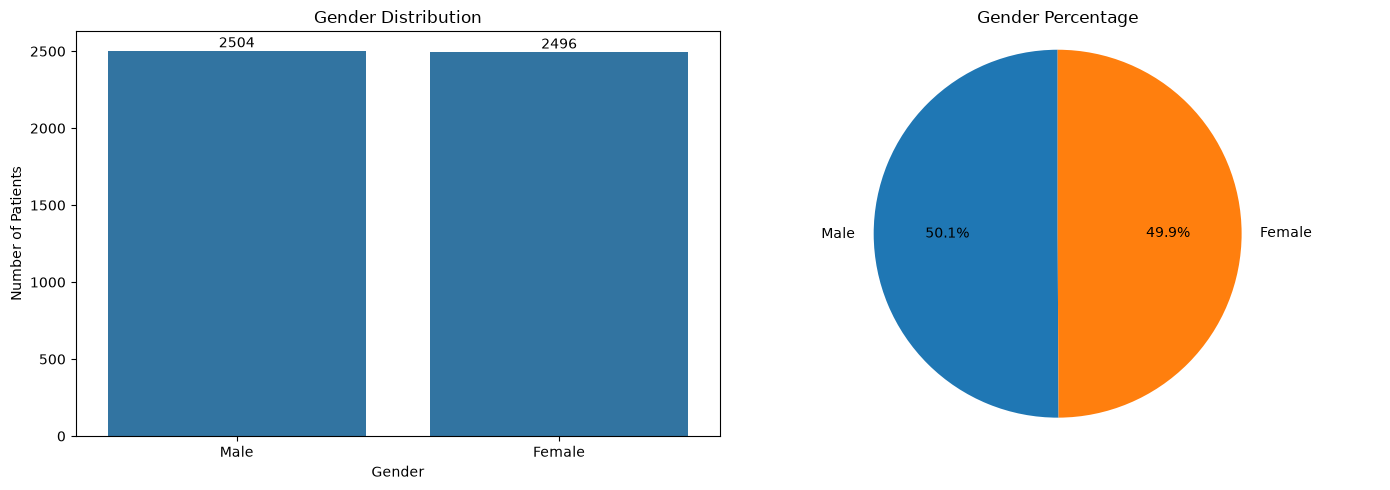

In [39]:
Gender_counts = patients_df_copy["Gender"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=Gender_counts.index,
    y=Gender_counts.values,
    ax=ax[0]
)

for container in ax[0].containers:
    ax[0].bar_label(container)

ax[0].set_title("Gender Distribution")
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Number of Patients")

ax[1].pie(
    Gender_counts,
    labels=Gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

ax[1].axis("equal")
ax[1].set_title("Gender Percentage")

plt.tight_layout()
plt.show()

**Task 23:** Visualize the Age distribution using a **Histogram**, and the distribution of Patients by Blood Type using a **Bar Chart**.

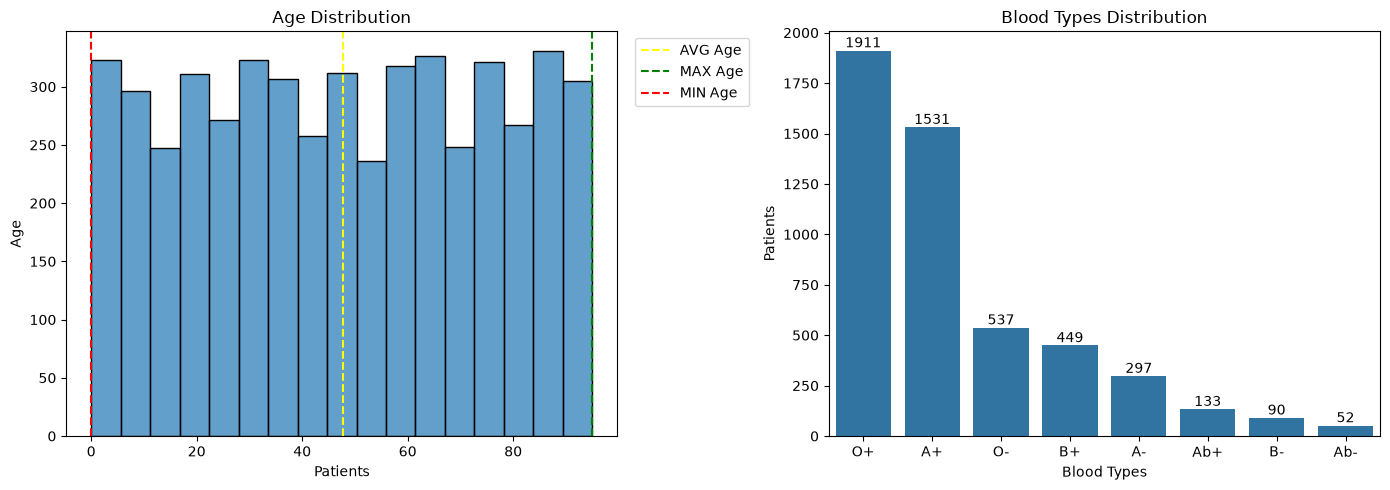

In [40]:
Blood_distribution=patients_df_copy['Blood_Type'].value_counts()

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.histplot(x='Age',data=patients_df_copy,edgecolor='Black',alpha=0.7,ax=ax[0])
Avg=Avg = patients_df_copy["Age"].mean()
ax[0].axvline(Avg,color='yellow',linestyle='--',label='AVG Age')
ax[0].axvline(x=patients_df_copy['Age'].max(),color='green',linestyle='--',label='MAX Age')
ax[0].axvline(x=patients_df_copy['Age'].min(),color='red',linestyle='--',label='MIN Age')

ax[0].set_xlabel("Patients")
ax[0].set_ylabel("Age")
ax[0].set_title("Age Distribution")

ax[0].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

sns.barplot(
    x=Blood_distribution.index,
    y=Blood_distribution.values,
    ax=ax[1]
)
for container in ax[1].containers:
    ax[1].bar_label(container)

ax[1].set_ylabel("Patients")
ax[1].set_xlabel("Blood Types")
ax[1].set_title("Blood Types Distribution")


plt.tight_layout()
plt.show()

**Task 24:** Visualize patient Registration by Month using a **Line Chart**, the AgeGroup counts (from `pd.cut()`) using a **Bar Chart**, and create a **Box Plot** for Age.

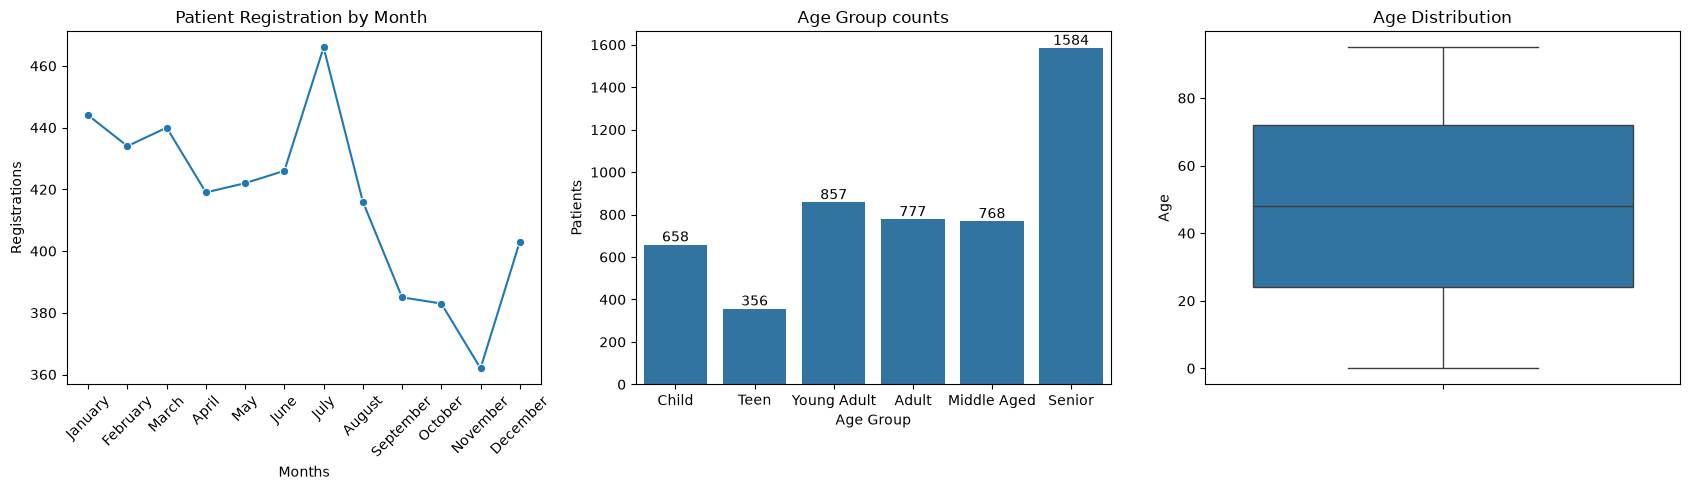

In [41]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

registration_by_month =patients_df_copy["RegMonth"].value_counts().reindex(month_order)

AgeGroup_counts=patients_df_copy['AgeGroup'].value_counts().sort_index()

fig,ax=plt.subplots(1,3,figsize=(17,5))
sns.lineplot(
    x=registration_by_month.index,
    y=registration_by_month.values,
    marker='o',
    ax=ax[0]
)

ax[0].set_xlabel("Months")
ax[0].set_ylabel("Registrations")
ax[0].set_title("Patient Registration by Month ")

ax[0].tick_params(axis="x", rotation=45)

sns.barplot(
    x=AgeGroup_counts.index,
    y=AgeGroup_counts.values,
    ax=ax[1]
)
for container in ax[1].containers:
    ax[1].bar_label(container)

ax[1].set_xlabel("Age Group")
ax[1].set_ylabel("Patients")
ax[1].set_title("Age Group counts")

sns.boxplot(y=patients_df_copy['Age'],ax=ax[2])
ax[2].set_title("Age Distribution")
ax[2].set_ylabel("Age")

plt.tight_layout()
plt.show()

## 3. Doctors Analysis

Repeat the same workflow on the `Doctors.csv` dataset.

**Task 25:** Load `Doctors.csv` into a DataFrame using `pd.read_csv()`, parsing any date column (e.g., joining date) using `parse_dates`.

In [42]:
Doctors_df=pd.read_sql("Select * from Doctors",conn)
Doctors_df.attrs['name']='Doctors DataFrame'
cleanner2=DataSetClean(Doctors_df)

C:\Users\usar\AppData\Local\Temp\ipykernel_22880\3428187208.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Doctors_df=pd.read_sql("Select * from Doctors",conn)


**Task 26:** Display the first 5 and last 5 rows using `head()` and `tail()`.

In [43]:
cleanner2.info()

,Doctor_ID,Doctor_Name,Gender,Specialty,Department,Years_of_Experience,Phone,Hire_Date
0,D001,Dr. Mahmoud Ayman Barakat,Male,Orthopedics,Orthopedics,3,+20 10-8000-9017,None
1,D002,Dr. Malak Tamer Shalaby,Female,Urology,Urology,14,+20 10-5977-7810,None
2,D003,Dr. Youssef Khalil,Male,Psychiatry,Psychiatry,23,+20 10-6676-1719,None
3,D004,Dr. Mariam Nabil Habib,Female,Neurology,Neurology,17,+20 10-0292-3425,None
4,D005,Dr. Anas Alaa El-Gendy,Male,Internal Medicine,Internal Medicine,30,+20 10-4483-8761,None


In [44]:
cleanner2.info()

,Doctor_ID,Doctor_Name,Gender,Specialty,Department,Years_of_Experience,Phone,Hire_Date
95,D096,Dr. Yehia Fahmy,Male,Radiology,Radiology,16,+20 10-2345-9314,None
96,D097,Dr. Emad Medhat Kamel,Male,Cardiology,Cardiology,23,+20 10-9629-1661,None
97,D098,Dr. Radwa Rashad,Female,General Surgery,Surgery,6,+20 10-2319-6018,None
98,D099,Dr. Wesam Fady El-Attar,Female,Oncology,Oncology,9,+20 10-3974-0114,None
99,D100,Dr. Randa Shawky,Female,General Surgery,Surgery,4,+20 10-0606-6032,None


**Task 27:** Display dataset information using `info()`, then generate descriptive statistics for all columns using `describe(include='all')`.

In [45]:
cleanner2.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Doctor_ID            100 non-null    str   
 1   Doctor_Name          100 non-null    str   
 2   Gender               100 non-null    str   
 3   Specialty            100 non-null    str   
 4   Department           100 non-null    str   
 5   Years_of_Experience  100 non-null    int64 
 6   Phone                100 non-null    str   
 7   Hire_Date            0 non-null      object
dtypes: int64(1), object(1), str(6)
memory usage: 6.4+ KB


In [46]:
cleanner2.info()

,Doctor_ID,Doctor_Name,Gender,Specialty,Department,Years_of_Experience,Phone,Hire_Date
count,100,100,100,100,100,100.000000,100,0
unique,100,100,2,15,15,NaN,100,0
top,D001,Dr. Mahmoud Ayman Barakat,Male,Internal Medicine,Internal Medicine,NaN,+20 10-8000-9017,NaN
freq,1,1,54,12,12,NaN,1,NaN
mean,NaN,NaN,NaN,NaN,NaN,17.300000,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,10.407359,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,16.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,NaN


**Task 28:** Print the shape, columns, and dtypes of the dataset, then find the unique values and counts for the Department and Specialty columns using `unique()` and `nunique()`.

In [47]:
cleanner2.info()

Doctor_ID                 str
Doctor_Name               str
Gender                    str
Specialty                 str
Department                str
Years_of_Experience     int64
Phone                     str
Hire_Date              object
dtype: object

In [48]:
cleanner2.DetectShape()

the shape of Doctors DataFrame is 100 row X 8 columns


In [49]:
cleanner2.info()

Index(['Doctor_ID', 'Doctor_Name', 'Gender', 'Specialty', 'Department',
       'Years_of_Experience', 'Phone', 'Hire_Date'],
      dtype='str')

In [50]:
cleanner2.Detect_UniqueValues()


The Unique values of The  Doctors DataFrame


{'Doctor_ID': <StringArray>
 ['D001', 'D002', 'D003', 'D004', 'D005', 'D006', 'D007', 'D008', 'D009',
  'D010', 'D011', 'D012', 'D013', 'D014', 'D015', 'D016', 'D017', 'D018',
  'D019', 'D020', 'D021', 'D022', 'D023', 'D024', 'D025', 'D026', 'D027',
  'D028', 'D029', 'D030', 'D031', 'D032', 'D033', 'D034', 'D035', 'D036',
  'D037', 'D038', 'D039', 'D040', 'D041', 'D042', 'D043', 'D044', 'D045',
  'D046', 'D047', 'D048', 'D049', 'D050', 'D051', 'D052', 'D053', 'D054',
  'D055', 'D056', 'D057', 'D058', 'D059', 'D060', 'D061', 'D062', 'D063',
  'D064', 'D065', 'D066', 'D067', 'D068', 'D069', 'D070', 'D071', 'D072',
  'D073', 'D074', 'D075', 'D076', 'D077', 'D078', 'D079', 'D080', 'D081',
  'D082', 'D083', 'D084', 'D085', 'D086', 'D087', 'D088', 'D089', 'D090',
  'D091', 'D092', 'D093', 'D094', 'D095', 'D096', 'D097', 'D098', 'D099',
  'D100']
 Length: 100, dtype: str,
 'Doctor_Name': <StringArray>
 [    'Dr. Mahmoud Ayman Barakat',       'Dr. Malak Tamer Shalaby',
             'Dr. Yousse

In [51]:
cleanner2.Detect_N_UniqueValues()

The Unique values of The  Doctors DataFrame


{'Doctor_ID': 100,
 'Doctor_Name': 100,
 'Gender': 2,
 'Specialty': 15,
 'Department': 15,
 'Years_of_Experience': 32,
 'Phone': 100,
 'Hire_Date': 0}

**Task 29:** Count the frequency of each Department using `value_counts()`, then show its percentage distribution using `value_counts(normalize=True)`.

In [52]:
Department_Freq=Doctors_df['Department'].value_counts()
Department_Freq


Department
Internal Medicine    12
Surgery              11
Ophthalmology        10
Oncology              9
Radiology             7
Cardiology            7
Emergency             7
Pediatrics            6
ENT                   6
Dermatology           6
Neurology             5
Urology               4
Psychiatry            4
Gynecology            4
Orthopedics           2
Name: count, dtype: int64

In [53]:
Department_Freq_percentage=Doctors_df['Department'].value_counts(normalize=True)
Department_Freq_percentage

Department
Internal Medicine    0.12
Surgery              0.11
Ophthalmology        0.10
Oncology             0.09
Radiology            0.07
Cardiology           0.07
Emergency            0.07
Pediatrics           0.06
ENT                  0.06
Dermatology          0.06
Neurology            0.05
Urology              0.04
Psychiatry           0.04
Gynecology           0.04
Orthopedics          0.02
Name: proportion, dtype: float64

**Task 30:** Check missing values using `isna().sum()` and `isna().mean()`, then drop any column exceeding a missing-value threshold you choose.

In [54]:
cleanner2.Detect_MissingValues()

Doctor_ID                0
Doctor_Name              0
Gender                   0
Specialty                0
Department               0
Years_of_Experience      0
Phone                    0
Hire_Date              100
dtype: int64

In [55]:
cleanner2.Detect_Percentage_MissingValues()

Doctor_ID                0.0
Doctor_Name              0.0
Gender                   0.0
Specialty                0.0
Department               0.0
Years_of_Experience      0.0
Phone                    0.0
Hire_Date              100.0
dtype: float64

In [56]:
cleanner2.Drop_ExceedsThrehold(0.8)

the ['Hire_Date'] dropped successfuly
 the new shape is (100, 7)


In [57]:
cleanner2.Detect_MissingValues()

Doctor_ID              0
Doctor_Name            0
Gender                 0
Specialty              0
Department             0
Years_of_Experience    0
Phone                  0
dtype: int64

In [58]:
cleanner2.Drop_ConstantColumns()

No constant columns found


**Task 31:** Fill missing values: use the median for Years of Experience, and the mode for Department and Specialty.

In [59]:
cleanner2.Fill_MissingValues()

The Dataset is Clean and Has No Missing Values


Doctor_ID              0
Doctor_Name            0
Gender                 0
Specialty              0
Department             0
Years_of_Experience    0
Phone                  0
dtype: int64

**Task 32:** Detect and remove duplicate rows using `duplicated()` and `drop_duplicates().reset_index(drop=True)`, then standardize text columns using `.str.capitalize()`.

In [60]:
cleanner2.Drop_Duplicates()

The data is clean - no duplicated rows were found


In [61]:
categorical_col=Doctors_df.select_dtypes(include='str').columns
Doctors_df[categorical_col]=Doctors_df[categorical_col].apply(lambda col : col.str.capitalize())

**Task 33:** Detect outliers in Years of Experience using the IQR method with `quantile()`.

In [62]:
cleanner2.Detect_outliers()

{'Years_of_Experience': 0}

**Task 34:** Create an `ExperienceLevel` column by binning Years of Experience into categories (e.g., Junior, Mid-level, Senior) using `pd.cut()`. Then group doctors by Department and calculate the count and average Years of Experience using `groupby().agg()` with named aggregation.

In [63]:
bins = [0, 5, 15, 35]
labels = [
    "Junior",
    "Mid-level",
    "Senior"
]
Doctors_df["ExperienceLevel"] = pd.cut(
    Doctors_df["Years_of_Experience"],
    bins=bins,
    labels=labels,
    include_lowest=True
    )
Doctors_df["ExperienceLevel"].value_counts()

ExperienceLevel
Senior       52
Mid-level    35
Junior       13
Name: count, dtype: int64

In [64]:
Doctors_analysis=Doctors_df.groupby('Department').agg(Doctors=('Doctor_ID','count'),
                                                      Average_Exp=('Years_of_Experience','mean')).sort_values('Doctors',ascending=False).round(2)
Doctors_analysis

,Doctors,Average_Exp
Department,,
Internal medicine,12,15.75
Surgery,11,12.45
Ophthalmology,10,19.40
Oncology,9,22.33
Radiology,7,19.00
Emergency,7,20.29
Cardiology,7,17.43
Pediatrics,6,13.33
Dermatology,6,20.17


**Task 35:** Visualize Doctors by Department using a **Bar Chart**, and Doctors by Specialty using a **Bar Chart**.

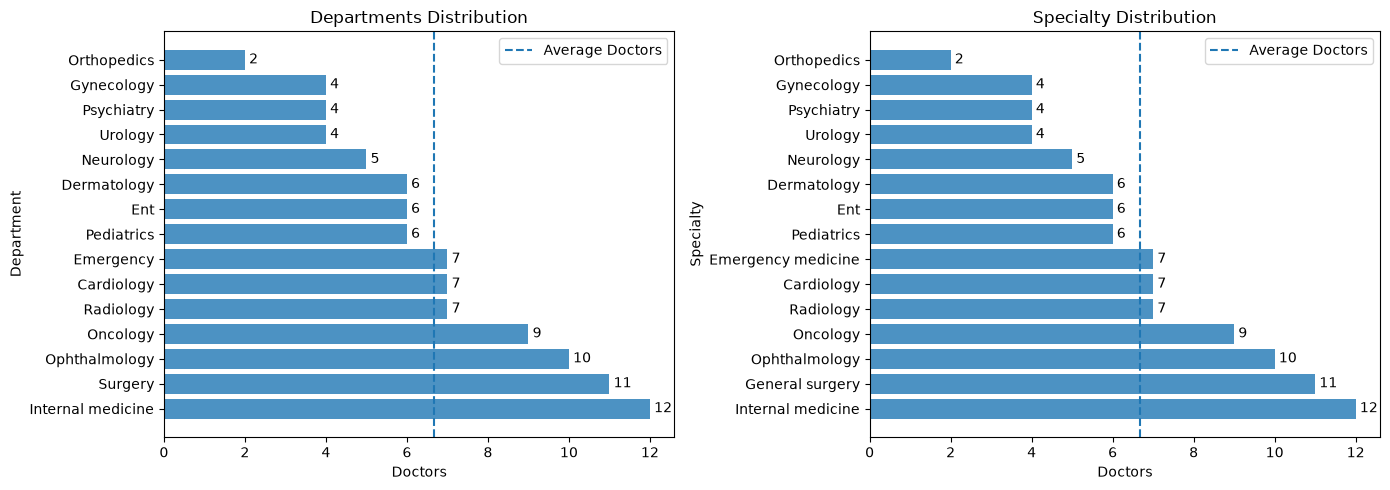

In [65]:
Doctors_by_dep=Doctors_df['Department'].value_counts()
Doctors_by_Specialty=Doctors_df['Specialty'].value_counts()
fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].barh(
    width=Doctors_by_dep.values,
    y=Doctors_by_dep.index,
    alpha=0.8,
)
for container in ax[0].containers:
    ax[0].bar_label(container, padding=3)

ax[0].axvline(x=Doctors_by_dep.values.mean(),linestyle='--',label='Average Doctors')
ax[0].legend()
ax[0].set_xlabel('Doctors')
ax[0].set_ylabel('Department')
ax[0].set_title('Departments Distribution')

ax[1].barh(
    width=Doctors_by_Specialty.values,
    y=Doctors_by_Specialty.index,
    alpha=0.8,
)
for container in ax[1].containers:
    ax[1].bar_label(container, padding=3)

ax[1].axvline(x=Doctors_by_Specialty.values.mean(),linestyle='--',label='Average Doctors')
ax[1].legend()
ax[1].set_xlabel('Doctors')
ax[1].set_ylabel('Specialty')
ax[1].set_title('Specialty Distribution')

plt.tight_layout()
plt.show()



**Task 36:** Visualize the Years of Experience Distribution using a **Histogram**, and create an Experience **Box Plot**.

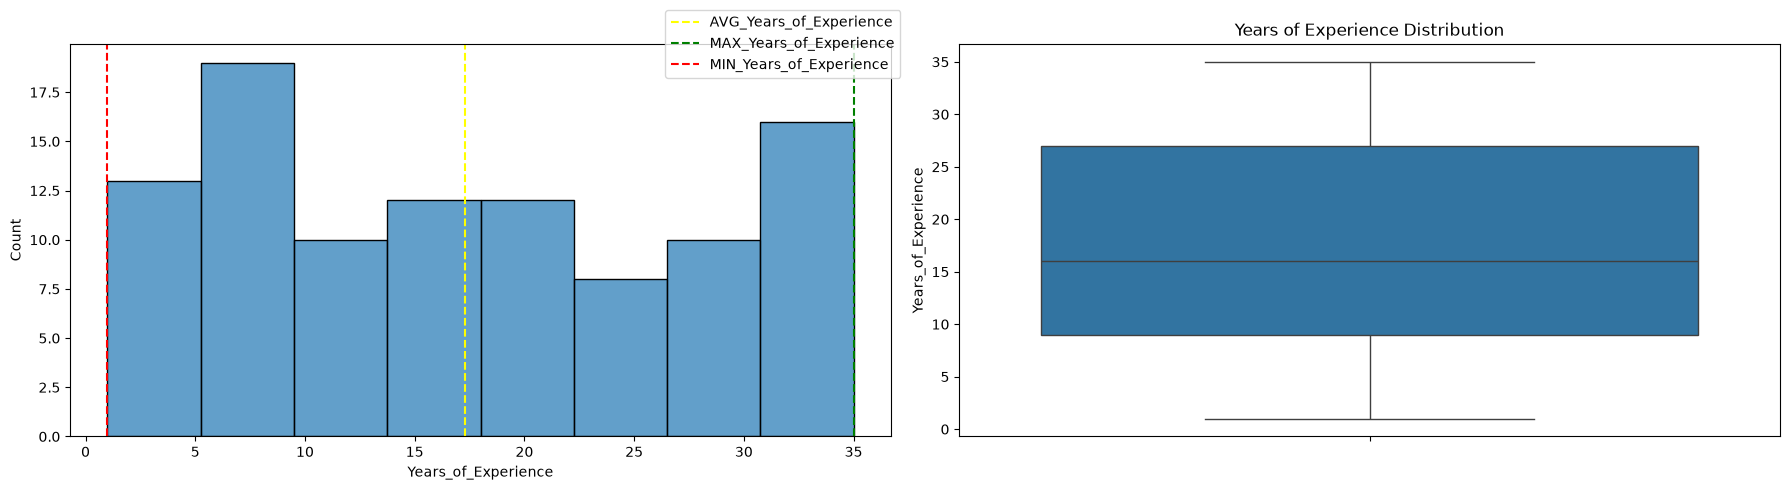

In [66]:
fig,ax=plt.subplots(1,2,figsize=(18,5))
sns.histplot(x='Years_of_Experience',data=Doctors_df,edgecolor='Black',alpha=0.7,ax=ax[0])
Avg=Doctors_df["Years_of_Experience"].mean()
ax[0].axvline(Avg,color='yellow',linestyle='--',label='AVG_Years_of_Experience')
ax[0].axvline(x=Doctors_df['Years_of_Experience'].max(),color='green',linestyle='--',label='MAX_Years_of_Experience')
ax[0].axvline(x=Doctors_df['Years_of_Experience'].min(),color='red',linestyle='--',label='MIN_Years_of_Experience')
ax[0].legend(   
    loc="center right",
    bbox_to_anchor=(1.02, 1)
)
sns.boxplot(y=Doctors_df["Years_of_Experience"],ax=ax[1])
ax[1].set_title("Years of Experience Distribution")

plt.tight_layout()
plt.show()

## 4. Appointments Analysis

Repeat the same workflow on the `Appointments.csv` dataset.

**Task 37:** Load `Appointments.csv` into a DataFrame using `pd.read_csv()`, parsing the appointment date column using `parse_dates`.

In [67]:
Appointments_df=pd.read_sql("select * from Appointments",conn,parse_dates=('Appointment_Date'))
Appointments_df.attrs['name']='Appointments DataFrame'
cleanner3=DataSetClean(Appointments_df)

C:\Users\usar\AppData\Local\Temp\ipykernel_22880\2039487288.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Appointments_df=pd.read_sql("select * from Appointments",conn,parse_dates=('Appointment_Date'))


**Task 38:** Display the first 5 and last 5 rows using `head()` and `tail()`.

In [68]:
cleanner3.info()

,Appointment_ID,Patient_ID,Doctor_ID,Appointment_Date,Appointment_Time,Status,Visit_Type
0,A00001,P01797,D094,2025-08-22,10:30:00,Completed,Follow-up\r
1,A00002,P00129,D069,2026-05-29,09:45:00,Cancelled,New\r
2,A00003,P02109,D081,2026-09-13,16:15:00,Scheduled,Consultation\r
3,A00004,P03623,D029,2023-10-01,12:15:00,Completed,Consultation\r
4,A00005,P04765,D081,2025-03-11,10:45:00,Cancelled,New\r


In [69]:
cleanner3.info()

,Appointment_ID,Patient_ID,Doctor_ID,Appointment_Date,Appointment_Time,Status,Visit_Type
9995,A09996,P04517,D092,2023-12-01,10:15:00,Completed,New\r
9996,A09997,P04860,D099,2024-01-02,14:30:00,Completed,Follow-up\r
9997,A09998,P00853,D039,2025-10-26,12:45:00,Completed,New\r
9998,A09999,P02776,D059,2023-02-06,11:00:00,Cancelled,Consultation\r
9999,A10000,P03301,D020,2025-10-05,14:00:00,Completed,Emergency\r


**Task 39:** Display dataset information using `info()`, then generate descriptive statistics using `describe(include='all')`.

In [70]:
cleanner3.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   Appointment_ID    10000 non-null  str          
 1   Patient_ID        10000 non-null  str          
 2   Doctor_ID         10000 non-null  str          
 3   Appointment_Date  10000 non-null  datetime64[s]
 4   Appointment_Time  10000 non-null  object       
 5   Status            10000 non-null  str          
 6   Visit_Type        10000 non-null  str          
dtypes: datetime64[s](1), object(1), str(5)
memory usage: 547.0+ KB


In [71]:
cleanner3.info()

,Appointment_ID,Patient_ID,Doctor_ID,Appointment_Date,Appointment_Time,Status,Visit_Type
count,10000,10000,10000,10000,10000,10000,10000
unique,10000,4313,100,NaN,36,3,4
top,A00001,P00036,D018,NaN,08:15:00,Completed,Follow-up\r
freq,1,8,124,NaN,319,7065,3462
mean,NaN,NaN,NaN,2025-02-14 11:38:32,NaN,NaN,NaN
min,NaN,NaN,NaN,2018-03-18 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,2024-05-23 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,2025-08-16 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,2026-05-09 00:00:00,NaN,NaN,NaN
max,NaN,NaN,NaN,2026-09-23 00:00:00,NaN,NaN,NaN


**Task 40:** Print the shape, columns, and dtypes of the dataset, then find the unique values and counts for the Status and Visit Type columns using `unique()` and `nunique()`.

In [72]:
cleanner3.DetectShape()

the shape of Appointments DataFrame is 10000 row X 7 columns


In [73]:
cleanner3.info()

Appointment_ID                str
Patient_ID                    str
Doctor_ID                     str
Appointment_Date    datetime64[s]
Appointment_Time           object
Status                        str
Visit_Type                    str
dtype: object

In [74]:
cleanner3.Detect_UniqueValues()

The Unique values of The  Appointments DataFrame


{'Appointment_ID': <StringArray>
 ['A00001', 'A00002', 'A00003', 'A00004', 'A00005', 'A00006', 'A00007',
  'A00008', 'A00009', 'A00010',
  ...
  'A09991', 'A09992', 'A09993', 'A09994', 'A09995', 'A09996', 'A09997',
  'A09998', 'A09999', 'A10000']
 Length: 10000, dtype: str,
 'Patient_ID': <StringArray>
 ['P01797', 'P00129', 'P02109', 'P03623', 'P04765', 'P01899', 'P01216',
  'P03764', 'P04667', 'P00173',
  ...
  'P03926', 'P01522', 'P00157', 'P00613', 'P00061', 'P04714', 'P02923',
  'P01813', 'P01553', 'P00776']
 Length: 4313, dtype: str,
 'Doctor_ID': <StringArray>
 ['D094', 'D069', 'D081', 'D029', 'D062', 'D024', 'D063', 'D040', 'D025',
  'D032', 'D018', 'D003', 'D070', 'D043', 'D006', 'D066', 'D004', 'D046',
  'D088', 'D079', 'D068', 'D086', 'D014', 'D092', 'D100', 'D050', 'D074',
  'D042', 'D041', 'D078', 'D011', 'D031', 'D047', 'D008', 'D059', 'D027',
  'D090', 'D048', 'D077', 'D019', 'D073', 'D096', 'D053', 'D015', 'D097',
  'D051', 'D055', 'D049', 'D007', 'D035', 'D021', 'D002',

In [75]:
cleanner3.Detect_N_UniqueValues()

The Unique values of The  Appointments DataFrame


{'Appointment_ID': 10000,
 'Patient_ID': 4313,
 'Doctor_ID': 100,
 'Appointment_Date': 2014,
 'Appointment_Time': 36,
 'Status': 3,
 'Visit_Type': 4}

**Task 41:** Count the frequency of each Status using `value_counts()`, then show its percentage distribution using `value_counts(normalize=True)`.

In [76]:
Appointments_df['Status'].value_counts()

Status
Completed    7065
Scheduled    1635
Cancelled    1300
Name: count, dtype: int64

In [77]:
Appointments_df['Status'].value_counts(normalize=True)

Status
Completed    0.7065
Scheduled    0.1635
Cancelled    0.1300
Name: proportion, dtype: float64

**Task 42:** Check missing values using `isna().sum()` and `isna().mean()`, then drop any column exceeding a missing-value threshold you choose.

In [78]:
cleanner3.Detect_MissingValues()

Appointment_ID      0
Patient_ID          0
Doctor_ID           0
Appointment_Date    0
Appointment_Time    0
Status              0
Visit_Type          0
dtype: int64

In [79]:
cleanner3.Detect_Percentage_MissingValues()

Appointment_ID      0.0
Patient_ID          0.0
Doctor_ID           0.0
Appointment_Date    0.0
Appointment_Time    0.0
Status              0.0
Visit_Type          0.0
dtype: float64

In [80]:
cleanner3.Drop_ExceedsThrehold(0.8)

no columns exceeds the threshold


**Task 43:** Fill missing categorical values (Status, Visit Type) using the mode.

In [81]:
cleanner3.Fill_MissingValues()

The Dataset is Clean and Has No Missing Values


Appointment_ID      0
Patient_ID          0
Doctor_ID           0
Appointment_Date    0
Appointment_Time    0
Status              0
Visit_Type          0
dtype: int64

**Task 44:** Detect and remove duplicate rows using `duplicated()` and `drop_duplicates().reset_index(drop=True)`.

In [82]:
cleanner3.Drop_Duplicates()

The data is clean - no duplicated rows were found


**Task 45:** Convert the appointment date column to proper datetime format using `pd.to_datetime(errors="coerce")`, and count how many values failed conversion.

In [83]:
Appointments_df['Appointment_Date']=pd.to_datetime(Appointments_df['Appointment_Date'],errors='coerce')
failed_conversion =Appointments_df['Appointment_Date'].isna().sum()
failed_conversion

np.int64(0)

**Task 46:** Extract the appointment month and weekday from the appointment date column using the `.dt` accessor, and create a boolean column `IsCompleted` using `apply(lambda)` based on the Status column.

In [84]:
Month=Appointments_df['Appointment_Date'].dt.month_name()
monthly_counts =Month.value_counts()
monthly_counts

Appointment_Date
July         1150
August       1129
September    1062
June          963
May           927
March         807
April         758
January       697
December      689
February      645
November      602
October       571
Name: count, dtype: int64

In [85]:
weekday=Appointments_df['Appointment_Date'].dt.day_of_week
weekday.value_counts()

Appointment_Date
6    1466
1    1452
0    1442
2    1440
3    1425
5    1417
4    1358
Name: count, dtype: int64

In [86]:
Appointments_df['IsCompleted']=Appointments_df['Status'].apply(lambda x : x.capitalize()=='Completed')
Appointments_df['IsCompleted'].value_counts()

IsCompleted
True     7065
False    2935
Name: count, dtype: int64

**Task 47:** Group appointments by Status and Visit Type and calculate counts using `groupby().agg()` with named aggregation, then find the busiest month using `idxmax()`.

In [87]:
Appointments_df['Visit_Type']=Appointments_df['Visit_Type'].str.replace('\r','',regex=False)

In [88]:
Status_vs_VisitType=Appointments_df.groupby(['Status','Visit_Type']).agg(Appointment_counts=('Appointment_ID','count'))
Status_vs_VisitType

Appointment_counts
Status    Visit_Type                      
Cancelled Consultation                 269
          Emergency                    130
          Follow-up                    448
          New                          453
Completed Consultation                1459
          Emergency                    755
          Follow-up                   2423
          New                         2428
Scheduled Consultation                 327
          Emergency                    174
          Follow-up                    591
          New                          543

In [89]:
busiest_month=monthly_counts.idxmax()
busiest_month

'July'

**Task 48:** Visualize Appointments per Month using a **Line Chart**, and Appointment Status using a **Bar Chart**.

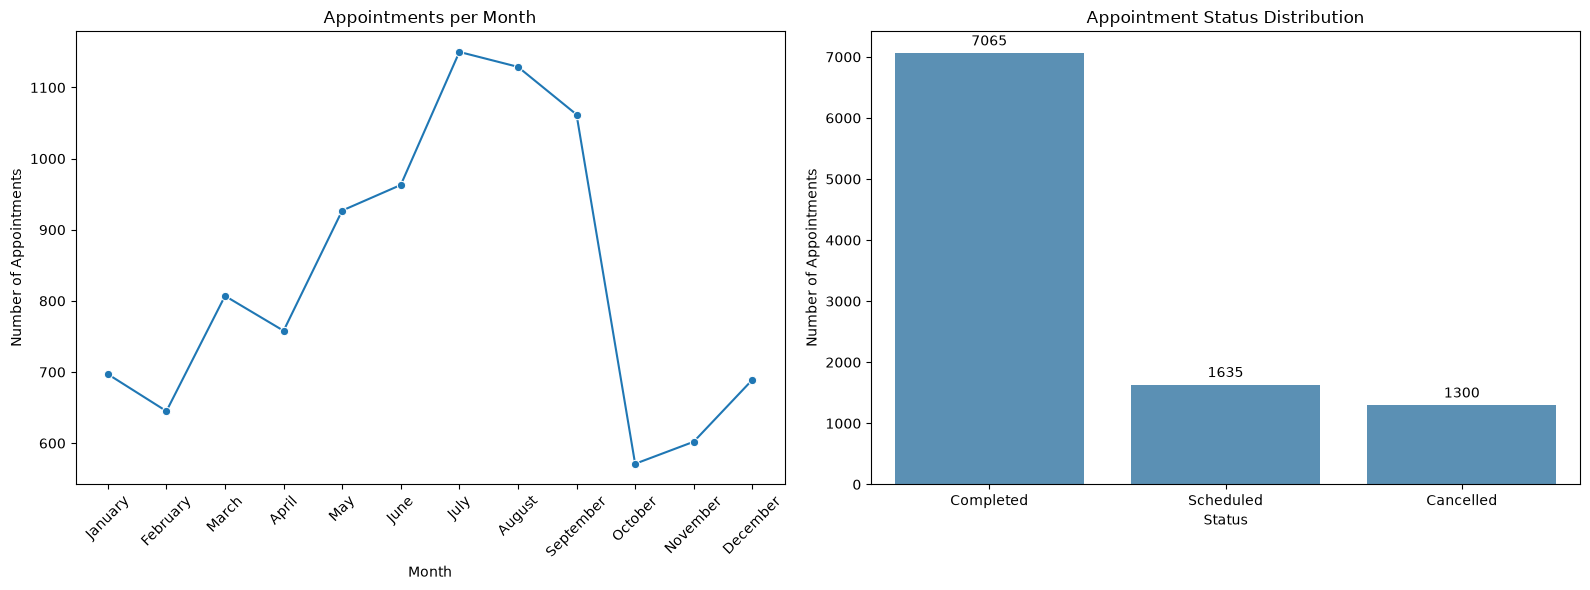

In [90]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]
appointments_by_month = (
    Appointments_df["Appointment_Date"]
    .dt.month_name()
    .value_counts()
    .reindex(month_order)
)

status_counts = Appointments_df["Status"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(
    x=appointments_by_month.index,
    y=appointments_by_month.values,
    marker='o',
    ax=ax[0]
)

ax[0].set_xlabel("Month")
ax[0].set_ylabel("Number of Appointments")
ax[0].set_title("Appointments per Month")

ax[0].tick_params(axis="x", rotation=45)

sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    alpha=0.8,
    ax=ax[1]
)

for container in ax[1].containers:
    ax[1].bar_label(container, padding=3)


ax[1].set_xlabel("Status")
ax[1].set_ylabel("Number of Appointments")
ax[1].set_title("Appointment Status Distribution")


plt.tight_layout()
plt.show()

**Task 49:** Visualize Visit Type using a **Bar Chart**, the Daily Appointment Trend using a **Line Chart**, and the Weekly Appointment Distribution using a **Bar Chart**.

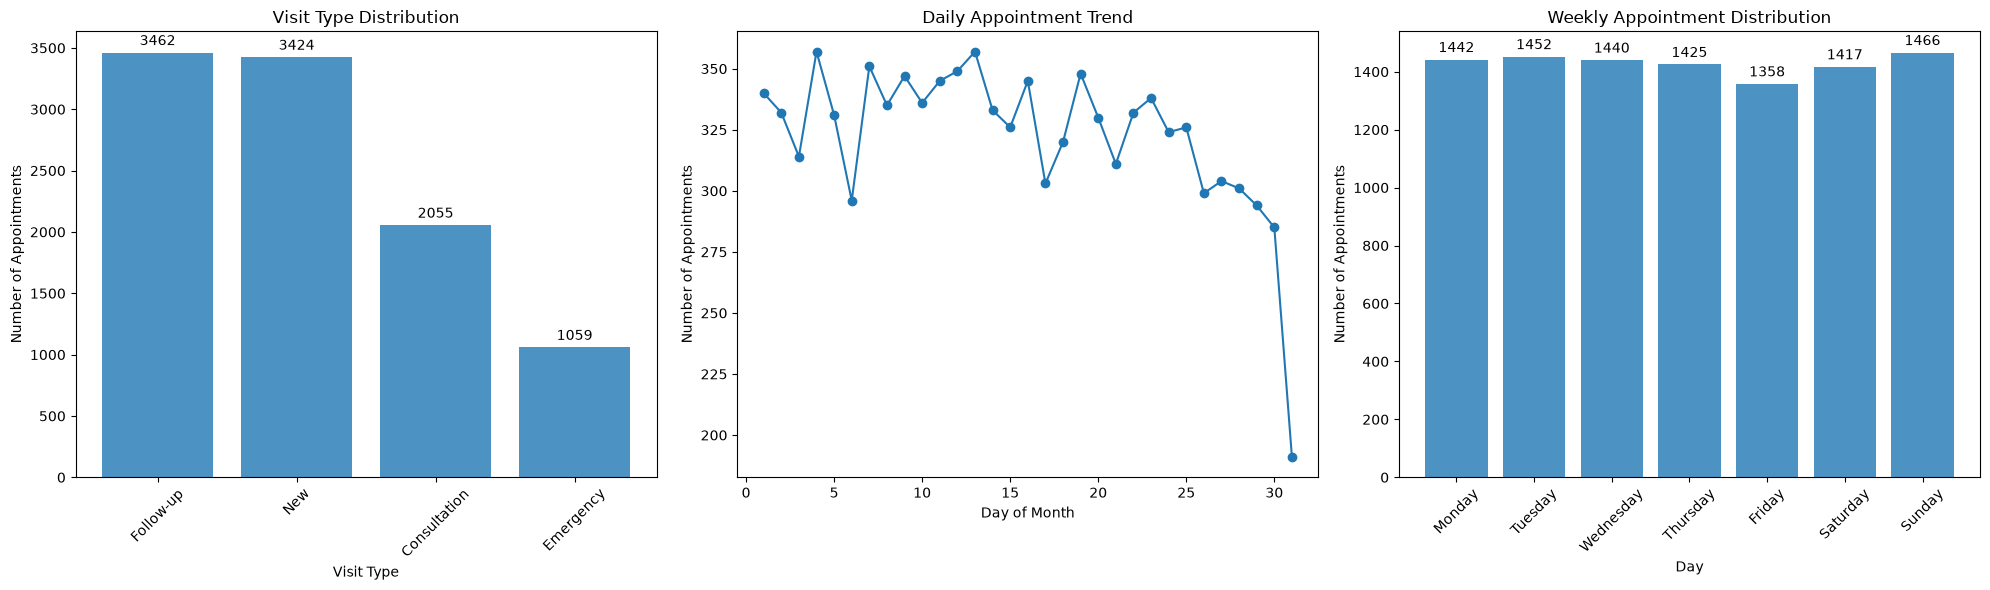

In [91]:
visit_type_counts = Appointments_df["Visit_Type"].value_counts()

daily_appointments = (
    Appointments_df["Appointment_Date"]
    .dt.day
    .value_counts()
    .sort_index()
)

Appointments_df["Day_Name"] = (
    Appointments_df["Appointment_Date"]
    .dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_appointments = (
    Appointments_df["Day_Name"]
    .value_counts()
    .reindex(day_order)
)


fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].bar(
    visit_type_counts.index,
    visit_type_counts.values,
    alpha=0.8
)

for container in ax[0].containers:
    ax[0].bar_label(container, padding=3)

ax[0].set_xlabel("Visit Type")
ax[0].set_ylabel("Number of Appointments")
ax[0].set_title("Visit Type Distribution")
ax[0].tick_params(axis="x", rotation=45)


ax[1].plot(
    daily_appointments.index,
    daily_appointments.values,
    marker='o'
)

ax[1].set_xlabel("Day of Month")
ax[1].set_ylabel("Number of Appointments")
ax[1].set_title("Daily Appointment Trend")



ax[2].bar(
    weekly_appointments.index,
    weekly_appointments.values,
    alpha=0.8
)

for container in ax[2].containers:
    ax[2].bar_label(container, padding=3)

ax[2].set_xlabel("Day")
ax[2].set_ylabel("Number of Appointments")
ax[2].set_title("Weekly Appointment Distribution")
ax[2].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

## 5. Medical Records Analysis

Repeat the same workflow on the `Medical_Records.csv` dataset.

**Task 50:** Load `Medical_Records.csv` into a DataFrame using `pd.read_csv()`, parsing the record date column using `parse_dates`.

In [92]:
Medical_Records_df=pd.read_sql("select * from Medical_Records",conn,parse_dates=('Record-date'))
Medical_Records_df.attrs['name']='Medical Records DataFrame'
cleanner4=DataSetClean(Medical_Records_df)

C:\Users\usar\AppData\Local\Temp\ipykernel_22880\3403431312.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Medical_Records_df=pd.read_sql("select * from Medical_Records",conn,parse_dates=('Record-date'))


**Task 51:** Display the first 5 and last 5 rows using `head()` and `tail()`, then display dataset information using `info()` and descriptive statistics using `describe(include='all')`.

In [93]:
cleanner4.info()

,Record_ID,Patient_ID,Doctor_ID,Diagnosis,Symptoms,Treatment,Record_Date
0,MR00001,P01870,D027,Urinary Tract Infection,"Burning urination, Frequent urge, Pelvic pain",Antibiotic course prescribed,None
1,MR00002,P04069,D065,Conjunctivitis,"Red eyes, Itching, Discharge",Antibiotic/antiviral eye drops,None
2,MR00003,P02877,D071,Urinary Tract Infection,"Burning urination, Frequent urge, Pelvic pain",Antibiotic course prescribed,None
3,MR00004,P02508,D052,Sinusitis,"Facial pain, Nasal congestion, Headache","Decongestants, antibiotics if bacterial",None
4,MR00005,P00718,D017,Anxiety Disorder,"Restlessness, Rapid heartbeat, Excessive worry","Counseling, anti-anxiety medication",None


In [94]:
cleanner4.info()

,Record_ID,Patient_ID,Doctor_ID,Diagnosis,Symptoms,Treatment,Record_Date
4995,MR04996,P04882,D033,Influenza,"Fever, Body aches, Chills, Fatigue","Antiviral medication, rest, hydration",None
4996,MR04997,P00028,D022,Common Cold,"Runny nose, Sore throat, Cough","Rest, fluids, symptomatic relief medication",None
4997,MR04998,P01595,D078,Hypertension,"Headache, Dizziness, Blurred vision","Prescribed antihypertensive medication, lifest...",None
4998,MR04999,P03317,D075,Type 2 Diabetes,"Fatigue, Frequent urination, Excessive thirst","Metformin prescribed, dietary counseling",None
4999,MR05000,P02527,D068,Urinary Tract Infection,"Burning urination, Frequent urge, Pelvic pain",Antibiotic course prescribed,None


In [95]:
cleanner4.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Record_ID    5000 non-null   str   
 1   Patient_ID   5000 non-null   str   
 2   Doctor_ID    5000 non-null   str   
 3   Diagnosis    5000 non-null   str   
 4   Symptoms     5000 non-null   str   
 5   Treatment    5000 non-null   str   
 6   Record_Date  0 non-null      object
dtypes: object(1), str(6)
memory usage: 273.6+ KB


**Task 52:** Print the shape, columns, and dtypes of the dataset, then find the unique values and counts for the Diagnosis column using `unique()` and `nunique()`.

In [96]:
cleanner4.DetectShape()

the shape of Medical Records DataFrame is 5000 row X 7 columns


In [97]:
cleanner4.info()

,Record_ID,Patient_ID,Doctor_ID,Diagnosis,Symptoms,Treatment,Record_Date
count,5000,5000,5000,5000,5000,5000,0
unique,5000,3145,100,20,20,20,0
top,MR00001,P03721,D034,Gastroenteritis,"Nausea, Vomiting, Diarrhea, Abdominal pain","Oral rehydration, dietary adjustment",NaN
freq,1,7,69,271,271,271,NaN


In [98]:
cleanner4.info()

Record_ID         str
Patient_ID        str
Doctor_ID         str
Diagnosis         str
Symptoms          str
Treatment         str
Record_Date    object
dtype: object

In [99]:
cleanner4.Detect_UniqueValues()

The Unique values of The  Medical Records DataFrame


{'Record_ID': <StringArray>
 ['MR00001', 'MR00002', 'MR00003', 'MR00004', 'MR00005', 'MR00006', 'MR00007',
  'MR00008', 'MR00009', 'MR00010',
  ...
  'MR04991', 'MR04992', 'MR04993', 'MR04994', 'MR04995', 'MR04996', 'MR04997',
  'MR04998', 'MR04999', 'MR05000']
 Length: 5000, dtype: str,
 'Patient_ID': <StringArray>
 ['P01870', 'P04069', 'P02877', 'P02508', 'P00718', 'P01063', 'P03685',
  'P02726', 'P04657', 'P03699',
  ...
  'P03845', 'P04274', 'P04841', 'P04775', 'P03561', 'P04354', 'P00232',
  'P04903', 'P04882', 'P03317']
 Length: 3145, dtype: str,
 'Doctor_ID': <StringArray>
 ['D027', 'D065', 'D071', 'D052', 'D017', 'D048', 'D057', 'D006', 'D016',
  'D087', 'D091', 'D021', 'D018', 'D003', 'D012', 'D094', 'D063', 'D020',
  'D088', 'D085', 'D030', 'D075', 'D010', 'D051', 'D034', 'D060', 'D089',
  'D098', 'D077', 'D043', 'D005', 'D009', 'D072', 'D024', 'D099', 'D069',
  'D008', 'D093', 'D033', 'D044', 'D076', 'D047', 'D083', 'D079', 'D078',
  'D046', 'D074', 'D038', 'D042', 'D004', '

In [100]:
cleanner4.Detect_N_UniqueValues()

The Unique values of The  Medical Records DataFrame


{'Record_ID': 5000,
 'Patient_ID': 3145,
 'Doctor_ID': 100,
 'Diagnosis': 20,
 'Symptoms': 20,
 'Treatment': 20,
 'Record_Date': 0}

**Task 53:** Count the frequency of each Diagnosis using `value_counts()`, then show its percentage distribution using `value_counts(normalize=True)`.

In [101]:
Medical_Records_df['Diagnosis'].value_counts()

Diagnosis
Gastroenteritis            271
Coronary Artery Disease    270
Asthma                     266
Sinusitis                  265
Bronchitis                 265
Thyroid Disorder           261
Common Cold                260
Hypertension               258
Conjunctivitis             257
Skin Allergy               256
Pneumonia                  246
Osteoarthritis             244
Urinary Tract Infection    242
Migraine                   240
Anxiety Disorder           239
Type 2 Diabetes            236
Influenza                  233
Depression                 231
Anemia                     230
Fracture                   230
Name: count, dtype: int64

In [102]:
Medical_Records_df['Diagnosis'].value_counts(normalize=True)

Diagnosis
Gastroenteritis            0.0542
Coronary Artery Disease    0.0540
Asthma                     0.0532
Sinusitis                  0.0530
Bronchitis                 0.0530
Thyroid Disorder           0.0522
Common Cold                0.0520
Hypertension               0.0516
Conjunctivitis             0.0514
Skin Allergy               0.0512
Pneumonia                  0.0492
Osteoarthritis             0.0488
Urinary Tract Infection    0.0484
Migraine                   0.0480
Anxiety Disorder           0.0478
Type 2 Diabetes            0.0472
Influenza                  0.0466
Depression                 0.0462
Anemia                     0.0460
Fracture                   0.0460
Name: proportion, dtype: float64

**Task 54:** Check missing values using `isna().sum()` and `isna().mean()`, then drop any column exceeding a missing-value threshold you choose.

In [103]:
cleanner4.Detect_MissingValues()

Record_ID         0
Patient_ID        0
Doctor_ID         0
Diagnosis         0
Symptoms          0
Treatment         0
Record_Date    5000
dtype: int64

In [104]:
cleanner4.Detect_Percentage_MissingValues()

Record_ID        0.0
Patient_ID       0.0
Doctor_ID        0.0
Diagnosis        0.0
Symptoms         0.0
Treatment        0.0
Record_Date    100.0
dtype: float64

In [105]:
cleanner4.Drop_ExceedsThrehold(0.8)

the ['Record_Date'] dropped successfuly
 the new shape is (5000, 6)


**Task 55:** Fill missing values in the Diagnosis or Notes columns using the mode or a custom placeholder value.

In [106]:
cleanner4.Fill_MissingValues()

The Dataset is Clean and Has No Missing Values


Record_ID     0
Patient_ID    0
Doctor_ID     0
Diagnosis     0
Symptoms      0
Treatment     0
dtype: int64

**Task 56:** Detect and remove duplicate rows using `duplicated()` and `drop_duplicates().reset_index(drop=True)`, then standardize the Diagnosis column using `.str.capitalize()`.

In [107]:
cleanner4.Drop_Duplicates()

The data is clean - no duplicated rows were found


In [108]:
Medical_Records_df['Diagnosis']=Medical_Records_df['Diagnosis'].str.capitalize()

**Task 58:** Visualize the Most Common Diagnoses using a **Bar Chart**

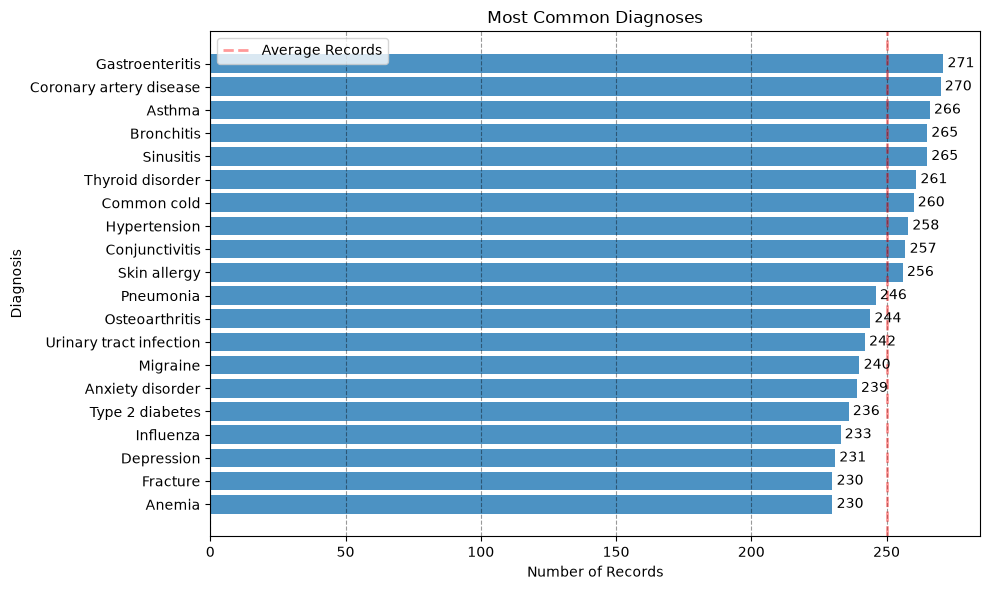

In [109]:
most_common_diagnoses=Medical_Records_df['Diagnosis'].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(axis='x', linestyle='--',color='black', alpha=0.4)
bars=ax.barh(
    width=most_common_diagnoses.values,
    y=most_common_diagnoses.index,
    alpha=0.8
)
ax.bar_label(bars,padding=3)

ax.axvline(x=most_common_diagnoses.values.mean(),linestyle='--',linewidth=2,color='red',label="Average Records",alpha=0.4)
ax.set_xlabel("Number of Records")
ax.set_ylabel("Diagnosis")
ax.set_title("Most Common Diagnoses")

ax.legend()
plt.tight_layout()
plt.show()



**Task 59:** Visualize Diagnosis Frequency by computing `value_counts(normalize=True).unstack()` and plotting the result as a **Bar Chart**.

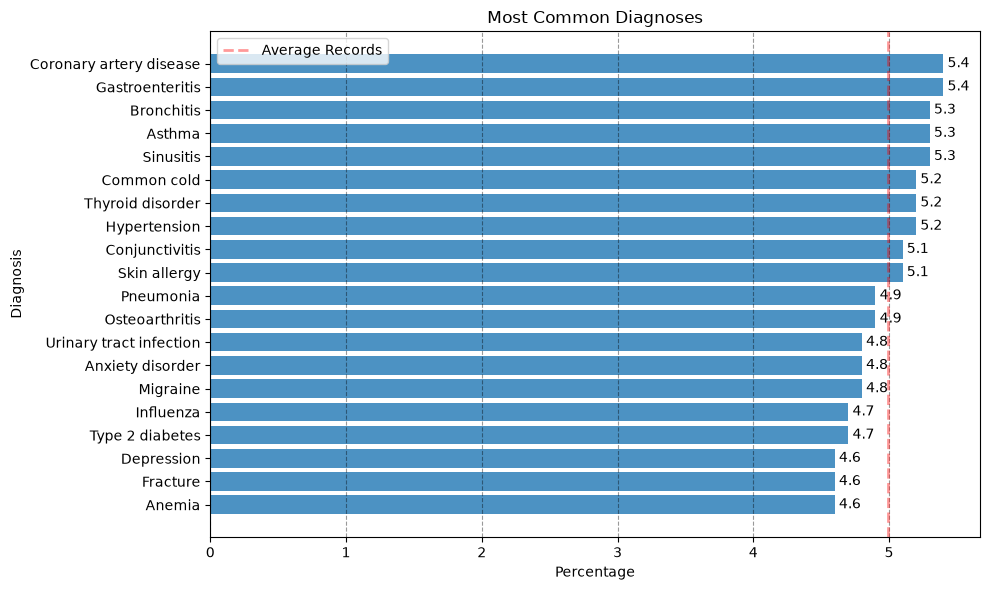

In [110]:
most_common_diagnoses2 = (
    Medical_Records_df["Diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .sort_values(ascending=True)
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(axis='x', linestyle='--',color='black', alpha=0.4)
bars=ax.barh(
    width=most_common_diagnoses2.values,
    y=most_common_diagnoses2.index,
    alpha=0.8
)
ax.bar_label(bars,padding=3)

ax.axvline(x=most_common_diagnoses2.values.mean(),linestyle='--',linewidth=2,color='red',label="Average Records",alpha=0.4)
ax.set_xlabel("Percentage")
ax.set_ylabel("Diagnosis")
ax.set_title("Most Common Diagnoses")

ax.legend()
plt.tight_layout()
plt.show()



## 6. Payments Analysis

Repeat the same workflow on the `Payments.csv` dataset.

**Task 60:** Load `Payments.csv` into a DataFrame using `pd.read_csv()`, parsing the payment date column using `parse_dates`.

In [111]:
Payments_df=pd.read_sql("Select * From Payments",conn,parse_dates='Payment_Date')
Payments_df.attrs['name']="Payments DataFrame"
cleanner5=DataSetClean(Payments_df)

C:\Users\usar\AppData\Local\Temp\ipykernel_22880\1035179178.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Payments_df=pd.read_sql("Select * From Payments",conn,parse_dates='Payment_Date')


**Task 61:** Display the first 5 and last 5 rows using `head()` and `tail()`, then display dataset information using `info()` and descriptive statistics using `describe(include='all')`.

In [112]:
cleanner5.info()

,Payment_ID,Patient_ID,Appointment_ID,Payment_Date,Amount,Payment_Method
0,PAY00001,P03602,A07878,2023-10-26,1346.35,Credit Card\r
1,PAY00002,P04297,A03349,2026-07-28,357.18,Credit Card\r
2,PAY00003,P03192,A07331,2026-08-16,371.31,Credit Card\r
3,PAY00004,P04942,A00761,2020-05-19,846.99,Insurance\r
4,PAY00005,P02247,A08744,2025-09-21,425.15,Insurance\r


In [113]:
cleanner5.info()

,Payment_ID,Patient_ID,Appointment_ID,Payment_Date,Amount,Payment_Method
11995,PAY11996,P04015,A06748,2022-08-14,1188.73,Insurance\r
11996,PAY11997,P02491,A01533,2025-08-16,906.03,Insurance\r
11997,PAY11998,P03030,A04989,2024-07-12,1645.92,Insurance\r
11998,PAY11999,P01249,A09989,2024-08-16,1975.97,Credit Card\r
11999,PAY12000,P00757,A02153,2023-06-20,431.48,Credit Card\r


In [114]:
cleanner5.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   Payment_ID      12000 non-null  str          
 1   Patient_ID      12000 non-null  str          
 2   Appointment_ID  12000 non-null  str          
 3   Payment_Date    12000 non-null  datetime64[s]
 4   Amount          12000 non-null  float64      
 5   Payment_Method  12000 non-null  str          
dtypes: datetime64[s](1), float64(1), str(4)
memory usage: 562.6 KB


In [115]:
cleanner5.info()

,Payment_ID,Patient_ID,Appointment_ID,Payment_Date,Amount,Payment_Method
count,12000,12000,12000,12000,12000.000000,12000
unique,12000,4129,8700,NaN,NaN,3
top,PAY00001,P03159,A08899,NaN,NaN,Cash\r
freq,1,12,6,NaN,NaN,4286
mean,NaN,NaN,NaN,2025-03-09 00:57:50,1018.262794,NaN
min,NaN,NaN,NaN,2018-03-25 00:00:00,50.010000,NaN
25%,NaN,NaN,NaN,2024-06-22 00:00:00,534.325000,NaN
50%,NaN,NaN,NaN,2025-09-13 00:00:00,1018.295000,NaN
75%,NaN,NaN,NaN,2026-05-28 00:00:00,1498.102500,NaN
max,NaN,NaN,NaN,2026-09-23 00:00:00,1999.950000,NaN


**Task 62:** Print the shape, columns, and dtypes of the dataset, then find the unique values and counts for the Payment Method column using `unique()` and `nunique()`.

In [116]:
cleanner5.DetectShape()

the shape of Payments DataFrame is 12000 row X 6 columns


In [117]:
cleanner5.info()

Payment_ID                  str
Patient_ID                  str
Appointment_ID              str
Payment_Date      datetime64[s]
Amount                  float64
Payment_Method              str
dtype: object

In [118]:
cleanner5.info()

Index(['Payment_ID', 'Patient_ID', 'Appointment_ID', 'Payment_Date', 'Amount',
       'Payment_Method'],
      dtype='str')

In [119]:
cleanner5.Detect_UniqueValues()

The Unique values of The  Payments DataFrame


{'Payment_ID': <StringArray>
 ['PAY00001', 'PAY00002', 'PAY00003', 'PAY00004', 'PAY00005', 'PAY00006',
  'PAY00007', 'PAY00008', 'PAY00009', 'PAY00010',
  ...
  'PAY11991', 'PAY11992', 'PAY11993', 'PAY11994', 'PAY11995', 'PAY11996',
  'PAY11997', 'PAY11998', 'PAY11999', 'PAY12000']
 Length: 12000, dtype: str,
 'Patient_ID': <StringArray>
 ['P03602', 'P04297', 'P03192', 'P04942', 'P02247', 'P00817', 'P03437',
  'P00468', 'P03535', 'P00125',
  ...
  'P01967', 'P01534', 'P02756', 'P04869', 'P00572', 'P01777', 'P04927',
  'P03611', 'P02256', 'P03164']
 Length: 4129, dtype: str,
 'Appointment_ID': <StringArray>
 ['A07878', 'A03349', 'A07331', 'A00761', 'A08744', 'A07282', 'A01655',
  'A00090', 'A07924', 'A00356',
  ...
  'A09567', 'A06435', 'A05097', 'A00533', 'A07199', 'A06604', 'A05984',
  'A06211', 'A00982', 'A08353']
 Length: 8700, dtype: str,
 'Payment_Date': <DatetimeArray>
 ['2023-10-26 00:00:00', '2026-07-28 00:00:00', '2026-08-16 00:00:00',
  '2020-05-19 00:00:00', '2025-09-21 00:0

In [120]:
cleanner5.Detect_N_UniqueValues()

The Unique values of The  Payments DataFrame


{'Payment_ID': 12000,
 'Patient_ID': 4129,
 'Appointment_ID': 8700,
 'Payment_Date': 2103,
 'Amount': 11633,
 'Payment_Method': 3}

**Task 63:** Count the frequency of each Payment Method using `value_counts()`, then show its percentage distribution using `value_counts(normalize=True)`.

In [121]:
Payments_df['Payment_Method']=Payments_df['Payment_Method'].str.replace('\r','',regex=False)

In [122]:
Freq_of_Payments=Payments_df['Payment_Method'].value_counts()
Freq_of_Payments

Payment_Method
Cash           4286
Insurance      4191
Credit Card    3523
Name: count, dtype: int64

In [123]:
Freq_of_Payments_Percentage=Payments_df['Payment_Method'].value_counts(normalize=True).mul(100).round(1)
Freq_of_Payments_Percentage

Payment_Method
Cash           35.7
Insurance      34.9
Credit Card    29.4
Name: proportion, dtype: float64

**Task 64:** Check missing values using `isna().sum()` and `isna().mean()`, then drop any column exceeding a missing-value threshold you choose.

In [124]:
cleanner5.Detect_MissingValues()

Payment_ID        0
Patient_ID        0
Appointment_ID    0
Payment_Date      0
Amount            0
Payment_Method    0
dtype: int64

In [125]:
cleanner5.Detect_Percentage_MissingValues()

Payment_ID        0.0
Patient_ID        0.0
Appointment_ID    0.0
Payment_Date      0.0
Amount            0.0
Payment_Method    0.0
dtype: float64

In [126]:
cleanner5.Drop_ExceedsThrehold(0.8)

no columns exceeds the threshold


**Task 65:** Fill missing values: use the median for the payment Amount column, and the mode for Payment Method.

In [127]:
cleanner5.Fill_MissingValues()

The Dataset is Clean and Has No Missing Values


Payment_ID        0
Patient_ID        0
Appointment_ID    0
Payment_Date      0
Amount            0
Payment_Method    0
dtype: int64

**Task 66:** Detect and remove duplicate rows using `duplicated()` and `drop_duplicates().reset_index(drop=True)`.

In [128]:
cleanner5.Drop_Duplicates()

The data is clean - no duplicated rows were found


**Task 67:** Detect outliers in the payment Amount column using the IQR method with `quantile()`.

In [129]:
cleanner5.Detect_outliers()

{'Amount': 0}

**Task 68:** Extract the payment month and year from the payment date column using the `.dt` accessor.

In [130]:
Payments_df['month']=Payments_df['Payment_Date'].dt.month_name()
Payments_df['month'].value_counts()

month
July         1515
August       1505
September    1287
June         1084
May          1037
March         933
April         890
January       826
December      792
February      770
November      693
October       668
Name: count, dtype: int64

In [131]:
Payments_df['Year']=Payments_df['Payment_Date'].dt.year
Payments_df['Year'].value_counts()

Year
2026    4932
2025    2977
2024    1796
2023    1017
2022     646
2021     350
2020     173
2019      84
2018      25
Name: count, dtype: int64

**Task 69:** Group payments by Payment Method and calculate the total and average revenue using `groupby().agg()` with named aggregation, then sort the results using `sort_values()`.

In [132]:
Payment_Methods_analysis=Payments_df.groupby('Payment_Method').agg(
    Total_Revenue=('Amount','sum'),
    Average_Revenue=('Amount','mean'),
    Transactions=("Payment_ID", "count")
).round(2).sort_values(by='Total_Revenue',ascending=False)
Payment_Methods_analysis

,Total_Revenue,Average_Revenue,Transactions
Payment_Method,,,
Cash,4368387.18,1019.22,4286
Insurance,4318002.75,1030.30,4191
Credit Card,3532763.60,1002.77,3523


**Task 70:** Visualize Monthly Revenue using a **Line Chart**, and Revenue by Payment Method using a **Bar Chart**.

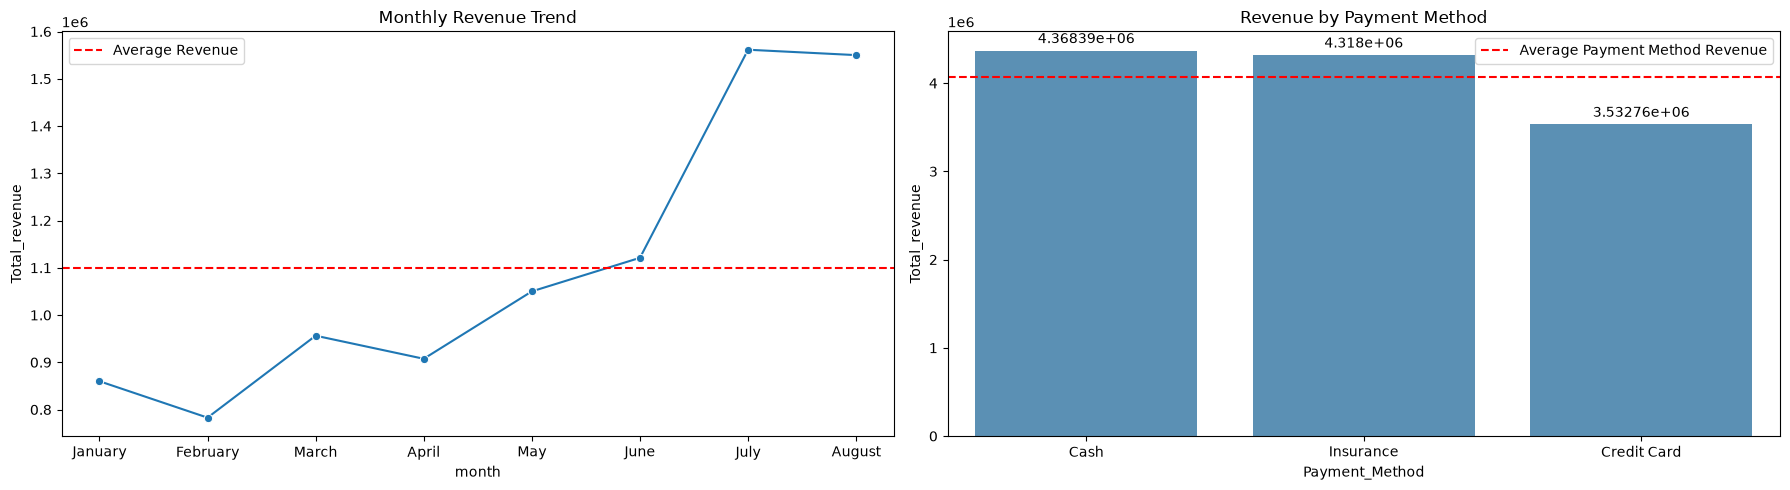

In [133]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
]
monthly_revenue=Payments_df.groupby('month').agg(Total_revenue=('Amount','sum')).reindex(month_order)
Payments_Method_revenue=Payments_df.groupby('Payment_Method').agg(Total_revenue=('Amount','sum')).sort_values(by='Total_revenue',ascending=False)
fig,ax=plt.subplots(1,2,figsize=(18,5))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue['Total_revenue'],
    marker='o',
    ax=ax[0]
)
ax[0].set_title("Monthly Revenue Trend")
ax[0].axhline(y=monthly_revenue['Total_revenue'].mean(),linestyle='--',color='red',label="Average Revenue")
ax[0].legend()

sns.barplot(
    x=Payments_Method_revenue.index,
    y=Payments_Method_revenue['Total_revenue'],
    alpha=0.8,
    ax=ax[1]
)

for container in ax[1].containers:
    ax[1].bar_label(container,padding=3)
    
ax[1].axhline(y=Payments_Method_revenue['Total_revenue'].mean(),linestyle='--',color='red',label="Average Payment Method Revenue")
ax[1].legend()
ax[1].set_title("Revenue by Payment Method")

plt.tight_layout()
plt.show()
    



**Task 71:** Visualize the Payment Amount Distribution using a **Histogram**, the Average Payment per Month using a **Line Chart**, and create a **Box Plot** for the Payment Amount.

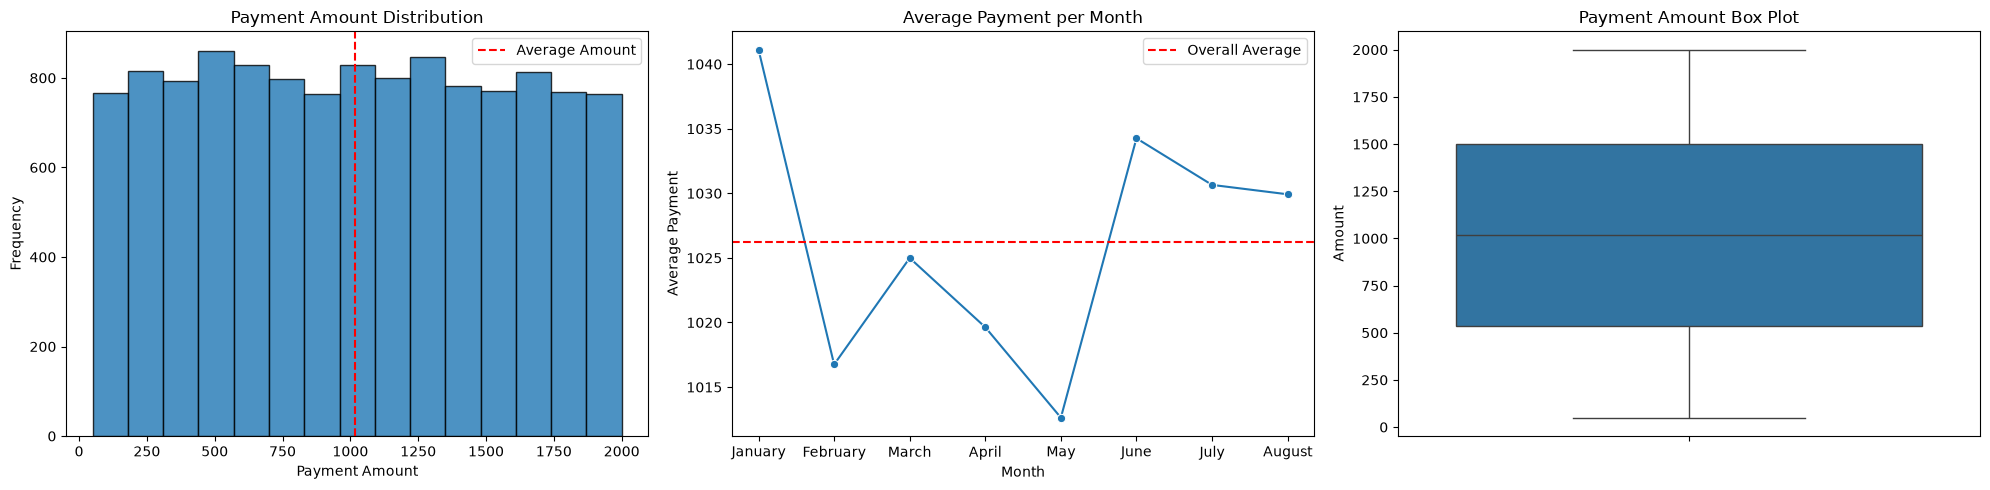

In [134]:
month_order = [
    "January","February","March","April",
    "May","June","July","August"
]
avg_payment_month = (
    Payments_df
    .groupby("month")
    .agg(Average_Payment=("Amount", "mean"))
    .reindex(month_order)
)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].hist(
    Payments_df["Amount"],
    bins=15,
    edgecolor="black",
    alpha=0.8
)
avg_amount = Payments_df["Amount"].mean()
ax[0].axvline(
    x=avg_amount,
    linestyle="--",
    color="red",
    label="Average Amount"
)

ax[0].set_title("Payment Amount Distribution")
ax[0].set_xlabel("Payment Amount")
ax[0].set_ylabel("Frequency")
ax[0].legend()


sns.lineplot(
    x=avg_payment_month.index,
    y=avg_payment_month["Average_Payment"],
    marker="o",
    ax=ax[1]
)

ax[1].axhline(
    y=avg_payment_month["Average_Payment"].mean(),
    linestyle="--",
    color="red",
    label="Overall Average"
)

ax[1].set_title("Average Payment per Month")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Average Payment")
ax[1].legend()



sns.boxplot(
    y=Payments_df["Amount"],
    ax=ax[2]
)
ax[2].set_title("Payment Amount Box Plot")
ax[2].set_ylabel("Amount")


plt.tight_layout()
plt.show()

## 7. Merge Tables & Business Analysis

Build the master dataset gradually using only `pd.merge()`. Right after each merge step, answer the business questions that merge makes possible, and create one small visualization tied to it -- instead of merging everything first and analyzing it all at the very end.

### 7.1 Patients <-> Appointments

**Task 72:** Merge the cleaned Patients and Appointments DataFrames using `pd.merge()` on the shared patient identifier, and check the resulting shape.

In [135]:
patients_With_Appointments=patients_df.merge(
    Appointments_df,
    how="left",
    on='Patient_ID'
)
patients_With_Appointments.attrs['name']='patients With Appointments DataFrame'
mergeCleanner=DataSetClean(patients_With_Appointments)
mergeCleanner.DetectShape()

the shape of patients With Appointments DataFrame is 10687 row X 17 columns


In [136]:
mergeCleanner.info()

,Patient_ID,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date,Appointment_ID,Doctor_ID,Appointment_Date,Appointment_Time,Status,Visit_Type,IsCompleted,Day_Name
0,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A00273,D020,2025-05-20,09:00:00,Completed,Follow-up,True,Tuesday
1,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A01979,D091,2024-09-21,08:00:00,Cancelled,Consultation,False,Saturday
2,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A07386,D054,2026-05-26,11:45:00,Completed,Consultation,True,Tuesday
3,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A09625,D090,2018-05-26,11:45:00,Completed,Follow-up,True,Saturday
4,P00002,Marwa Ibrahim El-Shazly,Female,1945-06-26,81,+20 12-3286-8828,"163 Al-Horreya St., New Cairo, Cairo",O-,2020-09-30,A08663,D018,2023-10-23,12:45:00,Completed,New,True,Monday


In [137]:
mergeCleanner.info()

,Patient_ID,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date,Appointment_ID,Doctor_ID,Appointment_Date,Appointment_Time,Status,Visit_Type,IsCompleted,Day_Name
10682,P04998,Heba Youssef,Female,1965-06-16,61,+20 12-7903-1028,"170 Al-Nozha St., Mallawi, Minya",A-,2024-10-18,A04084,D045,2025-01-16,12:30:00,Completed,Follow-up,True,Thursday
10683,P04998,Heba Youssef,Female,1965-06-16,61,+20 12-7903-1028,"170 Al-Nozha St., Mallawi, Minya",A-,2024-10-18,A09786,D062,2025-03-22,14:00:00,Completed,New,True,Saturday
10684,P04999,Mahmoud Soliman,Male,2014-03-25,12,+20 15-1282-3236,"Building 41, Apt. 40, Al-Merghany St., Belbeis...",O+,2025-09-18,A07874,D004,2026-07-04,16:15:00,Completed,Follow-up,True,Saturday
10685,P04999,Mahmoud Soliman,Male,2014-03-25,12,+20 15-1282-3236,"Building 41, Apt. 40, Al-Merghany St., Belbeis...",O+,2025-09-18,A09941,D038,2026-06-21,12:15:00,Completed,Emergency,True,Sunday
10686,P05000,Gamal Amer,Male,2024-01-11,2,+20 12-9401-3550,"Building 5, Apt. 29, Al-Gomhoreya St., Shubra,...",O+,2025-11-19,A09614,D051,2026-06-07,10:45:00,Completed,Follow-up,True,Sunday


**Task 73:** **Business Question:** Using this merged table, find the most active patients (the ones with the highest number of appointments) using `groupby()` and `sort_values()`.

In [138]:
Most_Active_Patient=patients_With_Appointments.groupby(["Patient_ID","Full_Name"]).agg(
    Number_Of_Appointments=('Appointment_ID','count')).sort_values('Number_Of_Appointments',ascending=False)
Most_Active_Patient.head(10)

,,Number_Of_Appointments
Patient_ID,Full_Name,
P00036,Osama El-Gendy,8
P04987,Yasmin Amr Kamel,7
P01690,Medhat Abdelrahman,7
P00961,Ashraf Amr Hassan,7
P00296,Adel Reda Amer,7
P04414,Ashraf Mazen Nassar,7
P03721,Sahar Fathy Nassar,7
P03771,Sahar Khaled Kamel,7
P03929,Reham Ezzat,7


In [139]:
completed_Appointments=patients_With_Appointments[patients_With_Appointments['Status']=='Completed']
Most_Active_Patient_completed=completed_Appointments.groupby(["Patient_ID","Full_Name"]).agg(
    Number_Of_Appointments=('Appointment_ID','count')).sort_values('Number_Of_Appointments',ascending=False).head(10)
Most_Active_Patient_completed

,,Number_Of_Appointments
Patient_ID,Full_Name,
P03721,Sahar Fathy Nassar,7
P01284,Emad Rashad,6
P03853,Toka Fady Selim,6
P00961,Ashraf Amr Hassan,6
P04584,Ramy Islam Tolba,6
P04414,Ashraf Mazen Nassar,6
P04486,Tamer Mazen Wahba,6
P04911,Abdelrahman Zidan,6
P00041,Dalia Khalil,6


In [140]:
Cancelled_Appointments=patients_With_Appointments[patients_With_Appointments['Status']=='Cancelled']
Most_Cancelled_Patient=Cancelled_Appointments.groupby(["Patient_ID","Full_Name"]).agg(
    Number_Of_Appointments_cancelled=('Appointment_ID','count')).sort_values('Number_Of_Appointments_cancelled',ascending=False).head(10)
Most_Cancelled_Patient

,,Number_Of_Appointments_cancelled
Patient_ID,Full_Name,
P00217,Reham Ahmed Soliman,3
P04234,Mahmoud Farid,3
P04404,Wafaa Bassem Barakat,3
P04348,Dalia El-Naggar,3
P02059,Passant Ayman Salama,3
P00818,Rana El-Attar,3
P02986,Adel Sayed Darwish,3
P04809,Omar Omar Ezzat,2
P04859,Heba Hussein Darwish,2


**Task 74:** **Visualization:** Visualize the Top 10 Patients by number of appointments using a **Bar Chart**.

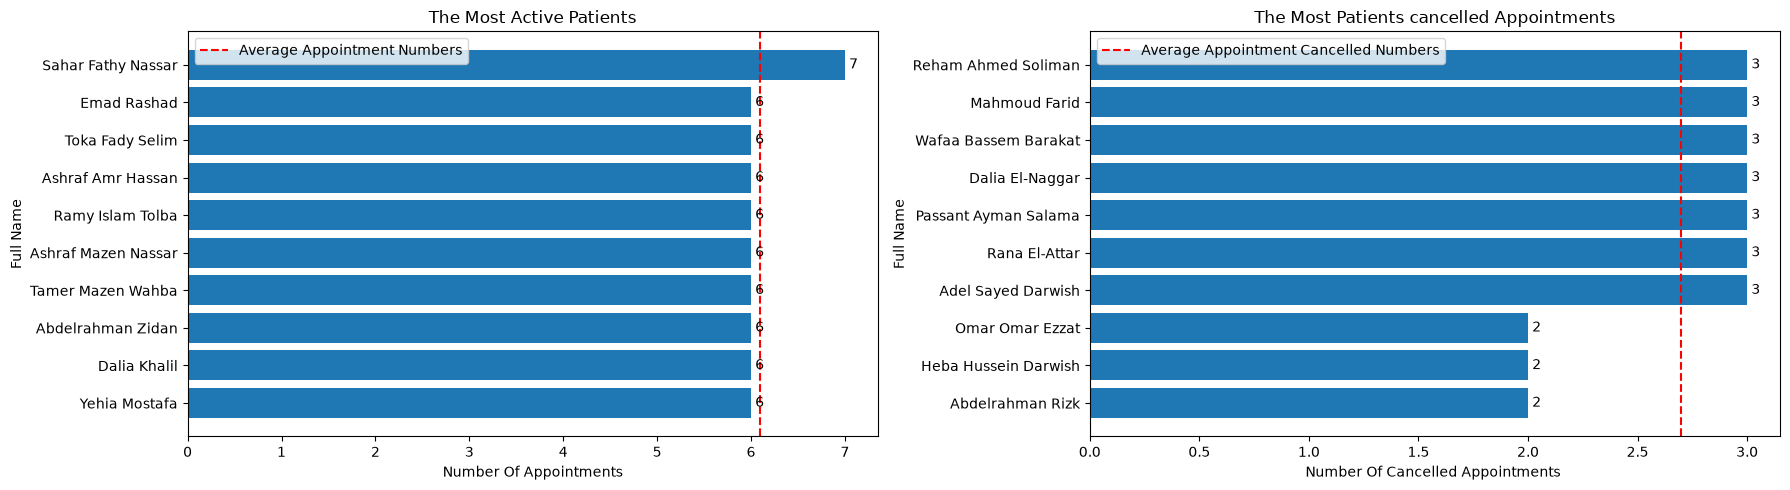

In [141]:
fig,ax=plt.subplots(1,2,figsize=(18,5))
bars=ax[0].barh(
    y=Most_Active_Patient_completed.index.get_level_values('Full_Name'),
    width=Most_Active_Patient_completed['Number_Of_Appointments'],
)

ax[0].bar_label(bars,padding= 3)
AVG_number=Most_Active_Patient_completed['Number_Of_Appointments'].mean()
ax[0].axvline(x=AVG_number,linestyle='--',color='red',label="Average Appointment Numbers")
ax[0].invert_yaxis()

ax[0].set_xlabel("Number Of Appointments")
ax[0].set_ylabel("Full Name")
ax[0].set_title("The Most Active Patients")
ax[0].legend()

bars=ax[1].barh(
    y=Most_Cancelled_Patient.index.get_level_values('Full_Name'),
    width=Most_Cancelled_Patient['Number_Of_Appointments_cancelled'],
)

ax[1].bar_label(bars,padding= 3)
AVG_number_cancelled=Most_Cancelled_Patient['Number_Of_Appointments_cancelled'].mean()
ax[1].axvline(x=AVG_number_cancelled,linestyle='--',color='red',label="Average Appointment Cancelled Numbers")
ax[1].invert_yaxis()

ax[1].set_xlabel("Number Of Cancelled Appointments ")
ax[1].set_ylabel("Full Name")
ax[1].set_title("The Most Patients cancelled Appointments")
ax[1].legend()



plt.tight_layout()
plt.show()

### 7.2 Doctors <-> Appointments

**Task 75:** Merge the cleaned Doctors DataFrame with Appointments using `pd.merge()` on the shared doctor identifier.

In [142]:
Doctors_with_Appointments=Doctors_df.merge(
    Appointments_df,
    how="left",
    on='Doctor_ID'
)
Doctors_with_Appointments.attrs['name']="Doctors with Appointments DataFrame"
mergeCleanner2=DataSetClean(Doctors_with_Appointments)

In [143]:
mergeCleanner2.DetectShape()

the shape of Doctors with Appointments DataFrame is 10000 row X 16 columns


In [144]:
mergeCleanner2.info()

,Doctor_ID,Doctor_Name,Gender,Specialty,Department,Years_of_Experience,Phone,ExperienceLevel,Appointment_ID,Patient_ID,Appointment_Date,Appointment_Time,Status,Visit_Type,IsCompleted,Day_Name
0,D001,Dr. mahmoud ayman barakat,Male,Orthopedics,Orthopedics,3,+20 10-8000-9017,Junior,A00402,P01248,2026-09-02,15:45:00,Scheduled,Consultation,False,Wednesday
1,D001,Dr. mahmoud ayman barakat,Male,Orthopedics,Orthopedics,3,+20 10-8000-9017,Junior,A00500,P03896,2025-10-26,09:00:00,Completed,Follow-up,True,Sunday
2,D001,Dr. mahmoud ayman barakat,Male,Orthopedics,Orthopedics,3,+20 10-8000-9017,Junior,A00640,P00573,2026-06-01,08:45:00,Completed,Follow-up,True,Monday
3,D001,Dr. mahmoud ayman barakat,Male,Orthopedics,Orthopedics,3,+20 10-8000-9017,Junior,A00743,P00133,2025-11-24,14:45:00,Scheduled,New,False,Monday
4,D001,Dr. mahmoud ayman barakat,Male,Orthopedics,Orthopedics,3,+20 10-8000-9017,Junior,A00994,P04347,2026-04-14,12:30:00,Completed,Follow-up,True,Tuesday


In [145]:
mergeCleanner2.info()

,Doctor_ID,Doctor_Name,Gender,Specialty,Department,Years_of_Experience,Phone,ExperienceLevel,Appointment_ID,Patient_ID,Appointment_Date,Appointment_Time,Status,Visit_Type,IsCompleted,Day_Name
9995,D100,Dr. randa shawky,Female,General surgery,Surgery,4,+20 10-0606-6032,Junior,A09121,P02481,2026-04-12,16:30:00,Completed,Consultation,True,Sunday
9996,D100,Dr. randa shawky,Female,General surgery,Surgery,4,+20 10-0606-6032,Junior,A09127,P02822,2026-03-29,16:15:00,Completed,Emergency,True,Sunday
9997,D100,Dr. randa shawky,Female,General surgery,Surgery,4,+20 10-0606-6032,Junior,A09181,P03007,2026-06-06,11:30:00,Completed,Consultation,True,Saturday
9998,D100,Dr. randa shawky,Female,General surgery,Surgery,4,+20 10-0606-6032,Junior,A09551,P00328,2026-04-23,08:15:00,Cancelled,New,False,Thursday
9999,D100,Dr. randa shawky,Female,General surgery,Surgery,4,+20 10-0606-6032,Junior,A09730,P01135,2026-07-15,11:30:00,Completed,Emergency,True,Wednesday


**Task 76:** **Business Question:** Using this merged table, find the doctors with the highest number of appointments, and identify which departments have the highest workload (most appointments), using `groupby().agg()` and `sort_values()`.

In [146]:
completed_Appointments_Doctors=Doctors_with_Appointments[Doctors_with_Appointments['Status']=='Completed']
Most_Active_Doctors_completed=completed_Appointments_Doctors.groupby(["Doctor_ID","Doctor_Name"]).agg(
    Number_Of_Appointments=('Appointment_ID','count')).sort_values('Number_Of_Appointments',ascending=False).head(10)
Most_Active_Doctors_completed

,,Number_Of_Appointments
Doctor_ID,Doctor_Name,
D034,Dr. fady younis,93
D018,Dr. hend kandil,91
D014,Dr. youssef anas anwar,88
D019,Dr. medhat omar wahba,88
D058,Dr. anas abdelrahman el-attar,88
D095,Dr. anas nabil shalaby,88
D063,Dr. mostafa fawzy,88
D003,Dr. youssef khalil,87
D098,Dr. radwa rashad,87


In [147]:
completed_Appointments_Dep=Doctors_with_Appointments[Doctors_with_Appointments['Status']=='Completed']
Most_Active_Dep_completed=completed_Appointments_Dep.groupby('Department').agg(
    Number_Of_Appointments=('Appointment_ID','count')).sort_values('Number_Of_Appointments',ascending=False).head(10)
Most_Active_Dep_completed

,Number_Of_Appointments
Department,
Internal medicine,834
Surgery,804
Ophthalmology,645
Oncology,609
Emergency,534
Radiology,522
Cardiology,498
Ent,458
Dermatology,429


**Task 77:** **Visualization:** Visualize the Top 10 Doctors by number of appointments using a **Bar Chart**, and Department Workload using a **Bar Chart**.

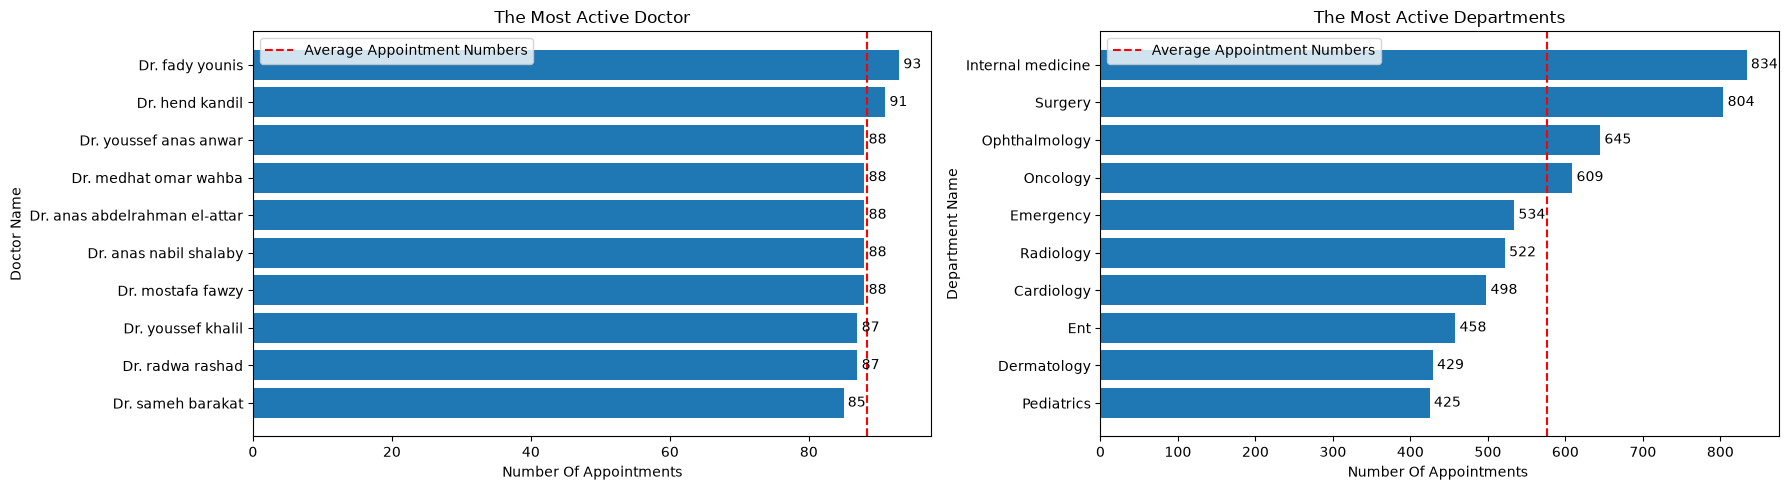

In [148]:
fig,ax=plt.subplots(1,2,figsize=(18,5))
bars=ax[0].barh(
    y=Most_Active_Doctors_completed.index.get_level_values('Doctor_Name'),
    width=Most_Active_Doctors_completed['Number_Of_Appointments'],
)

ax[0].bar_label(bars,padding= 3)
AVG_number_Doctors=Most_Active_Doctors_completed['Number_Of_Appointments'].mean()
ax[0].axvline(x=AVG_number_Doctors,linestyle='--',color='red',label="Average Appointment Numbers")
ax[0].invert_yaxis()

ax[0].set_xlabel("Number Of Appointments")
ax[0].set_ylabel("Doctor Name")
ax[0].set_title("The Most Active Doctor")
ax[0].legend()

bars=ax[1].barh(
    y=Most_Active_Dep_completed.index,
    width=Most_Active_Dep_completed['Number_Of_Appointments'],
)

ax[1].bar_label(bars,padding= 3)
AVG_number_Dep=Most_Active_Dep_completed['Number_Of_Appointments'].mean()
ax[1].axvline(x=AVG_number_Dep,linestyle='--',color='red',label="Average Appointment Numbers")
ax[1].invert_yaxis()

ax[1].set_xlabel("Number Of Appointments ")
ax[1].set_ylabel("Department Name")
ax[1].set_title("The Most Active Departments")
ax[1].legend()



plt.tight_layout()
plt.show()

### 7.3 Medical Records <-> Patients

**Task 78:** Merge the cleaned Medical Records DataFrame with Patients using `pd.merge()` on the shared patient identifier.

In [149]:
MedicalRecord_with_Patients=Medical_Records_df.merge(
    patients_df,
    how="left",
    on='Patient_ID'
)
MedicalRecord_with_Patients.attrs['name']="MedicalRecord with PatientsDataFrame"
mergeCleanner3=DataSetClean(MedicalRecord_with_Patients)

In [150]:
mergeCleanner3.info()

,Record_ID,Patient_ID,Doctor_ID,Diagnosis,Symptoms,Treatment,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date
0,MR00001,P01870,D027,Urinary tract infection,"Burning urination, Frequent urge, Pelvic pain",Antibiotic course prescribed,Nourhan Habib,Female,1984-05-06,42,+20 12-5141-1224,"116 Al-Nozha St., Damanhur, Beheira",O+,2019-12-10
1,MR00002,P04069,D065,Conjunctivitis,"Red eyes, Itching, Discharge",Antibiotic/antiviral eye drops,Wael Younis,Male,1994-08-11,31,+20 11-3865-6152,"Building 63, Apt. 39, Ramses St., Kafr El Daww...",O+,2023-04-26
2,MR00003,P02877,D071,Urinary tract infection,"Burning urination, Frequent urge, Pelvic pain",Antibiotic course prescribed,Osama Barakat,Male,1978-10-26,47,+20 11-2479-6255,"6 26th of July St., Naqada, Qena",Ab+,2022-09-06
3,MR00004,P02508,D052,Sinusitis,"Facial pain, Nasal congestion, Headache","Decongestants, antibiotics if bacterial",Shaimaa Medhat Shalaby,Female,1975-06-21,51,+20 11-5092-5964,"Building 55, Apt. 18, Suleiman Abaza St., Belb...",B+,2019-10-01
4,MR00005,P00718,D017,Anxiety disorder,"Restlessness, Rapid heartbeat, Excessive worry","Counseling, anti-anxiety medication",Hassan Karim Kandil,Male,2004-12-02,21,+20 15-7696-0402,"Building 34, Apt. 4, El-Tayaran St., New Cairo...",O-,2023-07-31


In [151]:
mergeCleanner3.info()

,Record_ID,Patient_ID,Doctor_ID,Diagnosis,Symptoms,Treatment,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date
4995,MR04996,P04882,D033,Influenza,"Fever, Body aches, Chills, Fatigue","Antiviral medication, rest, hydration",Sara Tamer Rashad,Female,1965-02-07,61,+20 11-6644-1201,"Building 51, Apt. 33, Al-Amir St., 10th of Ram...",B-,2020-06-21
4996,MR04997,P00028,D022,Common cold,"Runny nose, Sore throat, Cough","Rest, fluids, symptomatic relief medication",Sameh Karim Gomaa,Male,2023-04-01,3,+20 10-0615-0444,"56 Port Said St., Stanley, Alexandria",O+,2023-08-21
4997,MR04998,P01595,D078,Hypertension,"Headache, Dizziness, Blurred vision","Prescribed antihypertensive medication, lifest...",Ghada Ali Farid,Female,1931-03-03,95,+20 11-0777-2004,"Building 147, Apt. 17, Abbas El Akkad St., Bal...",O+,2024-05-17
4998,MR04999,P03317,D075,Type 2 diabetes,"Fatigue, Frequent urination, Excessive thirst","Metformin prescribed, dietary counseling",Bassem Osama Rashad,Male,1961-08-12,64,+20 10-1427-1532,"127 Talaat Harb St., Tanta, Gharbia",Ab+,2019-07-28
4999,MR05000,P02527,D068,Urinary tract infection,"Burning urination, Frequent urge, Pelvic pain",Antibiotic course prescribed,Medhat Abdelrahman Shawky,Male,1945-08-11,80,+20 10-2370-3827,"Building 25, Apt. 35, Al-Qasr Al-Aini St., Mia...",A+,2018-02-18


**Task 79:** **Business Question:** Using this merged table, find the most common diagnosis overall, and the most common diagnosis per Gender, using `value_counts()` and `groupby()`.

In [152]:
most_diagnoses_common=MedicalRecord_with_Patients['Diagnosis'].value_counts()
most_diagnoses_common

Diagnosis
Gastroenteritis            271
Coronary artery disease    270
Asthma                     266
Sinusitis                  265
Bronchitis                 265
Thyroid disorder           261
Common cold                260
Hypertension               258
Conjunctivitis             257
Skin allergy               256
Pneumonia                  246
Osteoarthritis             244
Urinary tract infection    242
Migraine                   240
Anxiety disorder           239
Type 2 diabetes            236
Influenza                  233
Depression                 231
Anemia                     230
Fracture                   230
Name: count, dtype: int64

In [153]:
Diagnosis_By_Gender = (
    MedicalRecord_with_Patients
    .groupby("Gender")
    .agg(
        Most_Common_Diagnosis=(
            "Diagnosis",
            lambda x: x.value_counts().idxmax()
        ),
        Number_Of_Cases=(
            "Diagnosis",
            lambda x: x.value_counts().max()
        )
    )
)

Diagnosis_By_Gender

,Most_Common_Diagnosis,Number_Of_Cases
Gender,,
Female,Sinusitis,148
Male,Thyroid disorder,148


**Task 80:** **Visualization:** Visualize the Most Common Diagnoses by Gender using a **Bar Chart**.

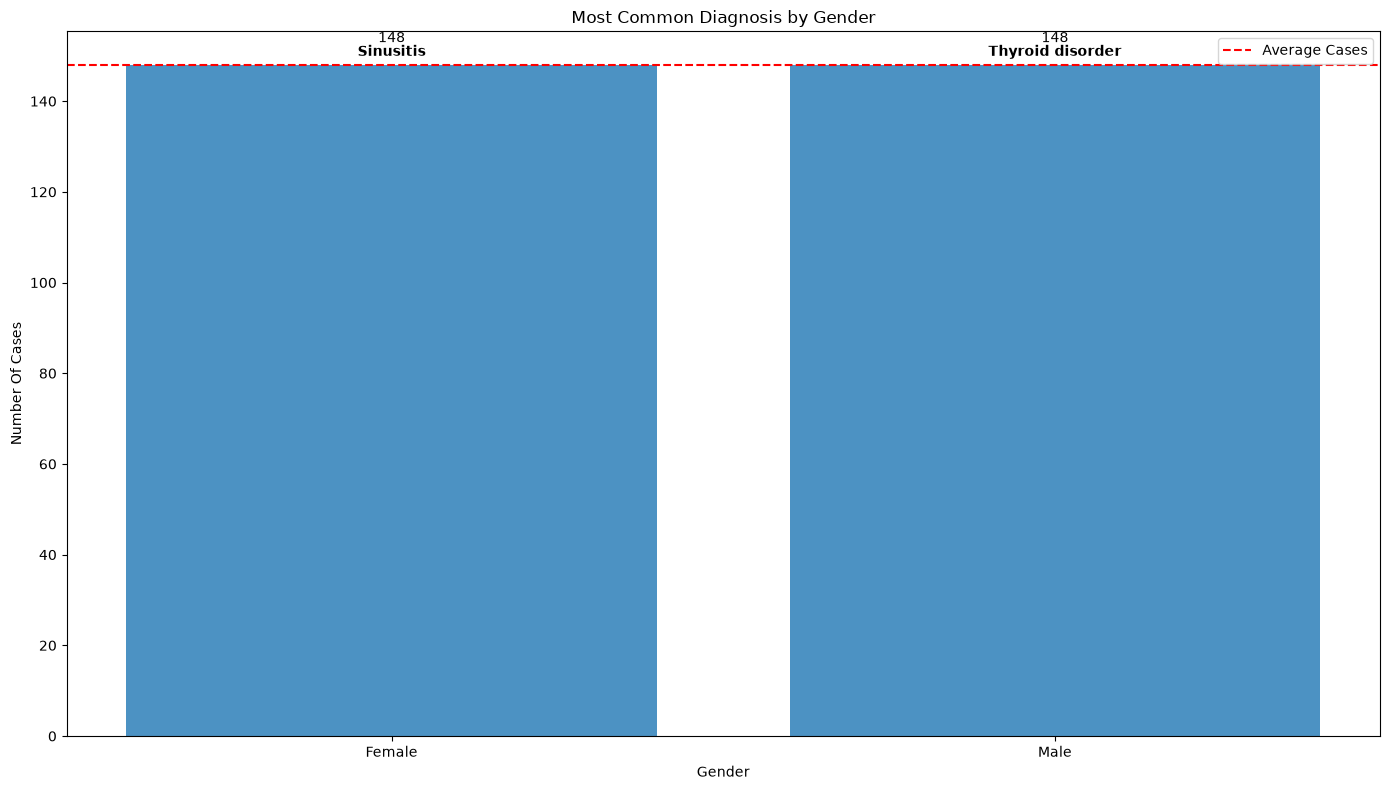

In [154]:
fig, ax = plt.subplots(figsize=(14,8))

bars = ax.bar(
    x=Diagnosis_By_Gender.index,
    height=Diagnosis_By_Gender["Number_Of_Cases"],
    alpha=0.8
)

ax.bar_label(bars, padding=14)

AVG_cases = Diagnosis_By_Gender["Number_Of_Cases"].mean()

ax.axhline(
    y=AVG_cases,
    linestyle="--",
    color="red",
    label="Average Cases"
)

for i, diagnosis in enumerate(Diagnosis_By_Gender["Most_Common_Diagnosis"]):
    ax.text(
        i,
        Diagnosis_By_Gender.iloc[i]["Number_Of_Cases"] + 2,
        diagnosis,
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlabel("Gender")
ax.set_ylabel("Number Of Cases")
ax.set_title("Most Common Diagnosis by Gender")

ax.legend()

plt.tight_layout()
plt.show()

### 7.4 Payments <-> Appointments

**Task 81:** Merge the cleaned Payments DataFrame with Appointments using `pd.merge()` on the shared appointment identifier.

In [155]:
Payments_With_Appointments=Payments_df.merge(
    Appointments_df,
    how="left",
    on='Appointment_ID'
)
Payments_With_Appointments.attrs['name']='Payments With Appointments DataFrame'
mergeCleanner4=DataSetClean(patients_With_Appointments)
mergeCleanner4.DetectShape()

the shape of patients With Appointments DataFrame is 10687 row X 17 columns


In [156]:
mergeCleanner4.info()

,Patient_ID,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date,Appointment_ID,Doctor_ID,Appointment_Date,Appointment_Time,Status,Visit_Type,IsCompleted,Day_Name
0,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A00273,D020,2025-05-20,09:00:00,Completed,Follow-up,True,Tuesday
1,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A01979,D091,2024-09-21,08:00:00,Cancelled,Consultation,False,Saturday
2,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A07386,D054,2026-05-26,11:45:00,Completed,Consultation,True,Tuesday
3,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A09625,D090,2018-05-26,11:45:00,Completed,Follow-up,True,Saturday
4,P00002,Marwa Ibrahim El-Shazly,Female,1945-06-26,81,+20 12-3286-8828,"163 Al-Horreya St., New Cairo, Cairo",O-,2020-09-30,A08663,D018,2023-10-23,12:45:00,Completed,New,True,Monday


In [157]:
mergeCleanner4.info()

,Patient_ID,Full_Name,Gender,Date_of_Birth,Age,Phone,Address,Blood_Type,Registration_Date,Appointment_ID,Doctor_ID,Appointment_Date,Appointment_Time,Status,Visit_Type,IsCompleted,Day_Name
10682,P04998,Heba Youssef,Female,1965-06-16,61,+20 12-7903-1028,"170 Al-Nozha St., Mallawi, Minya",A-,2024-10-18,A04084,D045,2025-01-16,12:30:00,Completed,Follow-up,True,Thursday
10683,P04998,Heba Youssef,Female,1965-06-16,61,+20 12-7903-1028,"170 Al-Nozha St., Mallawi, Minya",A-,2024-10-18,A09786,D062,2025-03-22,14:00:00,Completed,New,True,Saturday
10684,P04999,Mahmoud Soliman,Male,2014-03-25,12,+20 15-1282-3236,"Building 41, Apt. 40, Al-Merghany St., Belbeis...",O+,2025-09-18,A07874,D004,2026-07-04,16:15:00,Completed,Follow-up,True,Saturday
10685,P04999,Mahmoud Soliman,Male,2014-03-25,12,+20 15-1282-3236,"Building 41, Apt. 40, Al-Merghany St., Belbeis...",O+,2025-09-18,A09941,D038,2026-06-21,12:15:00,Completed,Emergency,True,Sunday
10686,P05000,Gamal Amer,Male,2024-01-11,2,+20 12-9401-3550,"Building 5, Apt. 29, Al-Gomhoreya St., Shubra,...",O+,2025-11-19,A09614,D051,2026-06-07,10:45:00,Completed,Follow-up,True,Sunday


**Task 82:** **Business Question:** Using this merged table, calculate total monthly revenue, and revenue by Visit Type, using the `.dt` accessor and `groupby().agg()`.

In [158]:
Payments_With_Appointments["Payment_Month"] = (
    Payments_With_Appointments["Payment_Date"]
    .dt.month_name()
)
Monthly_Revenue = (
    Payments_With_Appointments
    .groupby("Payment_Month")
    .agg(
        Total_Revenue=("Amount", "sum")
    )
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
)
Monthly_Revenue


,Total_Revenue
Payment_Month,
July,1561436.46
August,1550034.36
September,1251779.15
June,1121134.84
May,1050099.17
March,956317.27
April,907471.18
January,859960.66
December,793939.63


In [159]:
Revenue_By_Visit_Type = (
    Payments_With_Appointments
    .groupby("Visit_Type")
    .agg(
        Total_Revenue=("Amount", "sum"),
    )
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
)

Revenue_By_Visit_Type

,Total_Revenue
Visit_Type,
Follow-up,4240435.74
New,4202673.28
Consultation,2477599.65
Emergency,1298444.86


**Task 83:** **Visualization:** Visualize Monthly Revenue using a **Line Chart**, and Revenue by Visit Type using a **Bar Chart**.

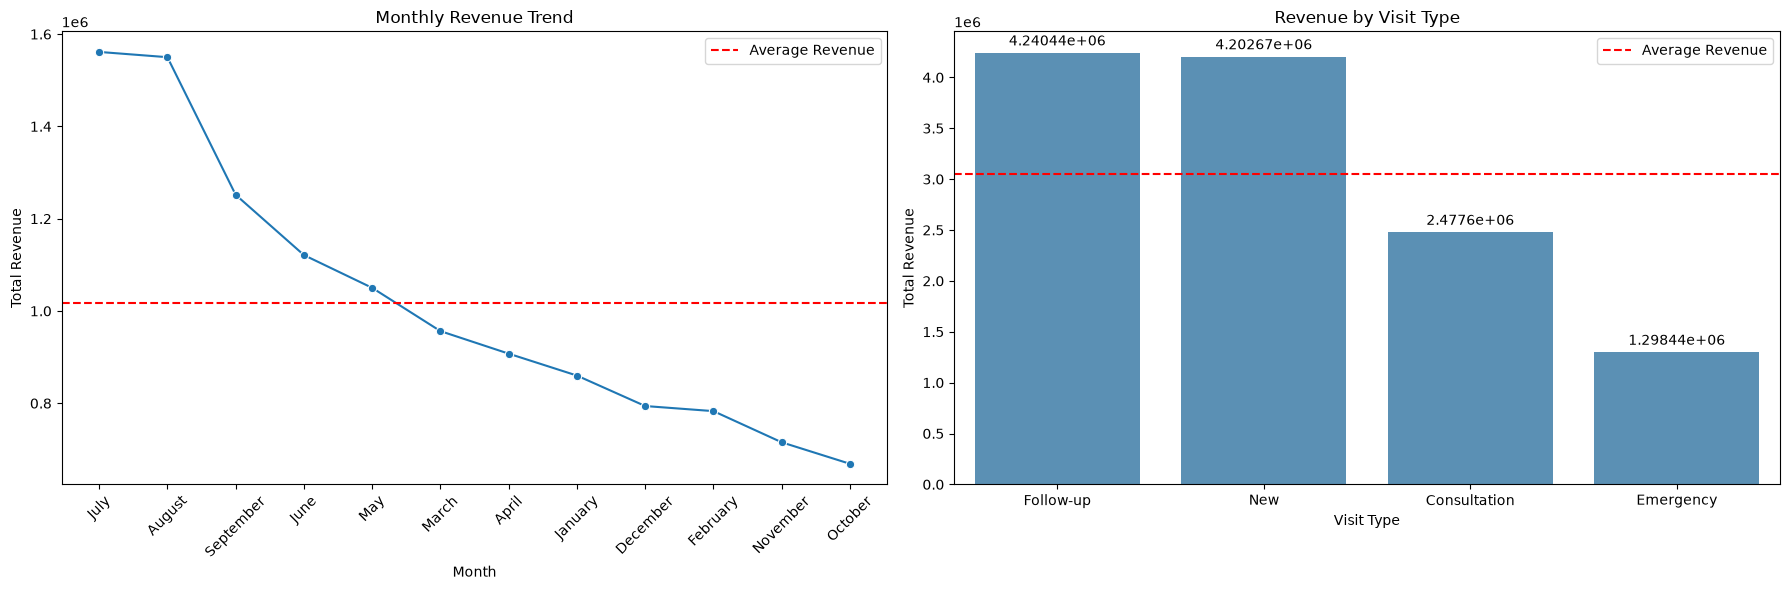

In [160]:
fig, ax = plt.subplots(1, 2, figsize=(18,6))

sns.lineplot(
    x=Monthly_Revenue.index,
    y=Monthly_Revenue["Total_Revenue"],
    marker="o",
    ax=ax[0]
)

ax[0].set_title("Monthly Revenue Trend")
ax[0].set_xlabel("Month")
ax[0].set_ylabel("Total Revenue")

avg_revenue = Monthly_Revenue["Total_Revenue"].mean()

ax[0].axhline(
    y=avg_revenue,
    linestyle="--",
    color="red",
    label="Average Revenue"
)

ax[0].legend()
ax[0].tick_params(axis='x',rotation=45)


bars = sns.barplot(
    x=Revenue_By_Visit_Type.index,
    y=Revenue_By_Visit_Type["Total_Revenue"],
    alpha=0.8,
    ax=ax[1]
)

ax[1].bar_label(bars.containers[0], padding=3)

avg_visit_revenue = Revenue_By_Visit_Type["Total_Revenue"].mean()

ax[1].axhline(
    y=avg_visit_revenue,
    linestyle="--",
    color="red",
    label="Average Revenue"
)


ax[1].set_title("Revenue by Visit Type")
ax[1].set_xlabel("Visit Type")
ax[1].set_ylabel("Total Revenue")

ax[1].legend()


plt.tight_layout()
plt.show()

### 7.5 Building the Master Table

**Task 84:** Merge the Patients+Appointments result (from 7.1) with the Doctors DataFrame, then merge that result with Payments, so each appointment row now includes both doctor and payment details.

In [163]:
patients_Appointments_Doctors=patients_With_Appointments.merge(
    Doctors_df,
    how='left',
    on='Doctor_ID'
)

master_table=patients_Appointments_Doctors.merge(
    Payments_df,
    how='left',
    on=["Appointment_ID", "Patient_ID"]
)

In [164]:
master_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 13987 entries, 0 to 13986
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   Patient_ID           13987 non-null  str          
 1   Full_Name            13987 non-null  str          
 2   Gender_x             13987 non-null  str          
 3   Date_of_Birth        13987 non-null  datetime64[s]
 4   Age                  13987 non-null  int64        
 5   Phone_x              13987 non-null  str          
 6   Address              13987 non-null  str          
 7   Blood_Type           13987 non-null  str          
 8   Registration_Date    13987 non-null  datetime64[s]
 9   Appointment_ID       13300 non-null  str          
 10  Doctor_ID            13300 non-null  str          
 11  Appointment_Date     13300 non-null  datetime64[s]
 12  Appointment_Time     13300 non-null  object       
 13  Status               13300 non-null  str          
 14  V

In [165]:
master_table = master_table.rename(
    columns={
        "Gender_x": "Patient_Gender",
        "Gender_y": "Doctor_Gender",
        "Phone_x": "Patient_Phone",
        "Phone_y": "Doctor_Phone"
    }
)

In [166]:
master_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 13987 entries, 0 to 13986
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   Patient_ID           13987 non-null  str          
 1   Full_Name            13987 non-null  str          
 2   Patient_Gender       13987 non-null  str          
 3   Date_of_Birth        13987 non-null  datetime64[s]
 4   Age                  13987 non-null  int64        
 5   Patient_Phone        13987 non-null  str          
 6   Address              13987 non-null  str          
 7   Blood_Type           13987 non-null  str          
 8   Registration_Date    13987 non-null  datetime64[s]
 9   Appointment_ID       13300 non-null  str          
 10  Doctor_ID            13300 non-null  str          
 11  Appointment_Date     13300 non-null  datetime64[s]
 12  Appointment_Time     13300 non-null  object       
 13  Status               13300 non-null  str          
 14  V

In [202]:
master_table['Payment_ID'].duplicated().sum()

np.int64(1986)

In [203]:
Appointments_df['Appointment_ID'].duplicated().sum()

np.int64(0)

**Task 85:** **Business Question:** Using this wider merged table, calculate the average number of appointments per doctor, the average payment per patient, the average payment per doctor, and total revenue by Department, using `groupby().agg()`.

In [171]:
Doctors_analysiss=(master_table
.groupby(['Doctor_ID','Doctor_Name'])
.agg(
    
    number_of_Appointments=('Appointment_ID','count'),
    Average_Payments=('Amount','mean')
    
    )
.sort_values(
    by='Average_Payments',
    ascending=False
)
).head(10)
Doctors_analysiss

,,number_of_Appointments,Average_Payments
Doctor_ID,Doctor_Name,,
D097,Dr. emad medhat kamel,113,1134.762200
D075,Dr. amira rizk,129,1121.291140
D004,Dr. mariam nabil habib,127,1117.434615
D099,Dr. wesam fady el-attar,131,1108.463363
D070,Dr. islam bassem gomaa,130,1104.763740
D086,Dr. sabry farid,134,1090.509833
D060,Dr. youssef barakat,152,1090.100357
D049,Dr. marwa gomaa,148,1089.672985
D030,Dr. ghada yasser hassan,115,1077.543960


In [173]:
Patients_analysis = (
    master_table
    .groupby(["Patient_ID", "Full_Name"])
    .agg(
        Average_Payment=("Amount", "mean")
    )
    .sort_values(
        "Average_Payment",
        ascending=False
    )
).head(10)

Patients_analysis

,,Average_Payment
Patient_ID,Full_Name,
P02878,Ahmed Anas Zaki,1999.41
P03818,Farida Anwar,1997.92
P03385,Reda Zaki,1996.85
P04193,Hesham Selim,1996.56
P01732,Sara El-Gendy,1993.07
P04396,Dina Hafez,1991.87
P04606,Khaled Yasser Wahba,1990.04
P00898,Marwa Magdy El-Attar,1987.93
P02403,Ayman Selim,1985.73


In [175]:
Department_analysis = (
    master_table
    .groupby("Department")
    .agg(
        Total_Revenue=("Amount", "sum")
    )
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
)

Department_analysis

,Total_Revenue
Department,
Internal medicine,1453182.10
Surgery,1376898.09
Ophthalmology,1211016.32
Oncology,1044331.21
Radiology,904317.82
Emergency,890637.19
Cardiology,872957.70
Pediatrics,771234.86
Ent,758847.44


**Task 86:** **Visualization:** Visualize Revenue by Department using a **Bar Chart**.

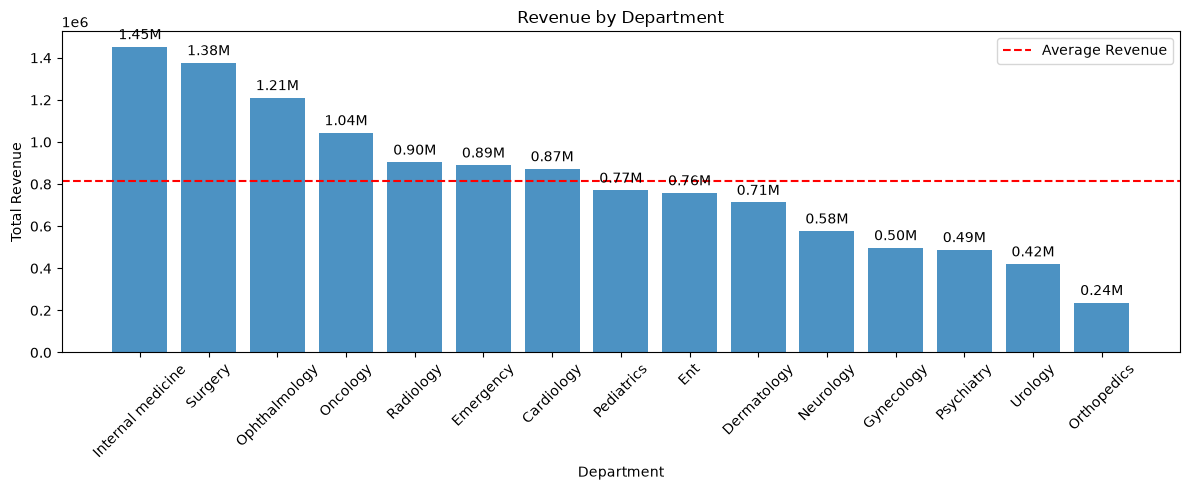

In [183]:
fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    Department_analysis.index,
    Department_analysis["Total_Revenue"],
    alpha=0.8
)

labels = [f"{x/1_000_000:.2f}M" for x in Department_analysis["Total_Revenue"]]

ax.bar_label(bars, labels=labels, padding=3)

AVG_Revenue = Department_analysis["Total_Revenue"].mean()

ax.axhline(
    y=AVG_Revenue,
    linestyle="--",
    color="red",
    label="Average Revenue"
)

ax.tick_params(axis="x", rotation=45)

ax.set_title("Revenue by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Total Revenue")

ax.legend()
plt.tight_layout()
plt.show()

**Task 87:** Merge all five cleaned tables (Patients, Doctors, Appointments, Medical Records, Payments) together using a sequence of `pd.merge()` calls to build one master DataFrame, then verify its final shape and column list.

In [ ]:
all_tables = (
patients_df.merge(
        Appointments_df,
        on="Patient_ID",
        how="left"
).merge(
        Payments_df,
        on=["Appointment_ID", "Patient_ID"],
        how="left"
 ).merge(
        Medical_Records_df,
        on=["Patient_ID", "Doctor_ID"],
        how="left"
 ).merge(
        Doctors_df,
        on="Doctor_ID",
        how="left"
 )
)

In [191]:
all_tables.info()

<class 'pandas.DataFrame'>
RangeIndex: 14075 entries, 0 to 14074
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   Patient_ID           14075 non-null  str          
 1   Full_Name            14075 non-null  str          
 2   Gender_x             14075 non-null  str          
 3   Date_of_Birth        14075 non-null  datetime64[s]
 4   Age                  14075 non-null  int64        
 5   Phone_x              14075 non-null  str          
 6   Address              14075 non-null  str          
 7   Blood_Type           14075 non-null  str          
 8   Registration_Date    14075 non-null  datetime64[s]
 9   Appointment_ID       13388 non-null  str          
 10  Doctor_ID            13388 non-null  str          
 11  Appointment_Date     13388 non-null  datetime64[s]
 12  Appointment_Time     13388 non-null  object       
 13  Status               13388 non-null  str          
 14  V

In [193]:
print(list(all_tables.columns))

['Patient_ID', 'Full_Name', 'Gender_x', 'Date_of_Birth', 'Age', 'Phone_x', 'Address', 'Blood_Type', 'Registration_Date', 'Appointment_ID', 'Doctor_ID', 'Appointment_Date', 'Appointment_Time', 'Status', 'Visit_Type', 'IsCompleted', 'Day_Name', 'Payment_ID', 'Payment_Date', 'Amount', 'Payment_Method', 'month', 'Year', 'Record_ID', 'Diagnosis', 'Symptoms', 'Treatment', 'Doctor_Name', 'Gender_y', 'Specialty', 'Department', 'Years_of_Experience', 'Phone_y', 'ExperienceLevel']


In [194]:
all_tables = all_tables.rename(
    columns={
        "Gender_x": "Patient_Gender",
        "Gender_y": "Doctor_Gender",
        "Phone_x": "Patient_Phone",
        "Phone_y": "Doctor_Phone"
    }
)

In [195]:
all_tables.shape

(14075, 34)

In [196]:
all_tables.head()

,Patient_ID,Full_Name,Patient_Gender,Date_of_Birth,Age,Patient_Phone,Address,Blood_Type,Registration_Date,Appointment_ID,...,Diagnosis,Symptoms,Treatment,Doctor_Name,Doctor_Gender,Specialty,Department,Years_of_Experience,Doctor_Phone,ExperienceLevel
0,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A00273,...,Fracture,"Localized pain, Swelling, Limited mobility","Cast/splint applied, orthopedic follow-up",Dr. reham magdy hafez,Female,Cardiology,Cardiology,24.0,+20 10-9371-5125,Senior
1,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A01979,...,NaN,NaN,NaN,Dr. mostafa ahmed el-attar,Male,Emergency medicine,Emergency,33.0,+20 10-0666-2598,Senior
2,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A07386,...,NaN,NaN,NaN,Dr. fathy saad,Male,Gynecology,Gynecology,2.0,+20 10-1125-5120,Junior
3,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A07386,...,NaN,NaN,NaN,Dr. fathy saad,Male,Gynecology,Gynecology,2.0,+20 10-1125-5120,Junior
4,P00001,Ziad Khaled Abdallah,Male,1991-12-11,34,+20 10-0335-6886,"Building 143, Apt. 30, Al-Batal Ahmed Abdel Az...",B+,2018-04-13,A09625,...,Fracture,"Localized pain, Swelling, Limited mobility","Cast/splint applied, orthopedic follow-up",Dr. sherif farouk,Male,Pediatrics,Pediatrics,14.0,+20 10-1406-4838,Mid-level


**Task 88:** **Business Question:** Using the full master dataset, identify the top 10 paying patients, and calculate total revenue by Payment Method, using `groupby()` and `sort_values()`.

In [214]:
payment_duplicates = all_tables[
    all_tables['Payment_ID'].duplicated(keep=False)
].sort_values('Payment_ID')

payment_duplicates[['Amount','Payment_ID','Record_ID','Diagnosis','Patient_ID']].head(20)

# Warning:
# Merging Medical Records creates duplicate Payment_IDs because a single patient can have multiple diagnoses.
# Avoid calculating revenue directly from this table to prevent double-counting payments.

,Amount,Payment_ID,Record_ID,Diagnosis,Patient_ID
11155,981.24,PAY00144,MR04953,Osteoarthritis,P03963
11154,981.24,PAY00144,MR04526,Pneumonia,P03963
2025,440.02,PAY00153,MR04166,Asthma,P00708
2024,440.02,PAY00153,MR02771,Common cold,P00708
6247,185.64,PAY00248,MR04607,Urinary tract infection,P02213
6246,185.64,PAY00248,MR03195,Conjunctivitis,P02213
2692,1461.31,PAY00346,MR03652,Thyroid disorder,P00942
2691,1461.31,PAY00346,MR02026,Bronchitis,P00942
7404,197.91,PAY00618,MR00427,Sinusitis,P02629
7403,197.91,PAY00618,MR00207,Conjunctivitis,P02629


**Task 89:** **Business Question:** Using the full master dataset, analyze appointment trends over time and patient registration trends over time, using `groupby()` and the `.dt` accessor.

In [ ]:
appointment_trends = (
    master_table
    .assign(
        Appointment_Year = master_table['Appointment_Date'].dt.year,
        Appointment_Month = master_table['Appointment_Date'].dt.month_name()
    )
    .groupby(
        ['Appointment_Year','Appointment_Month']
  )
    .agg(
        Number_of_Appointments=('Appointment_ID','nunique')
)
    .reset_index()
)

appointment_trends.head(20)

,Appointment_Year,Appointment_Month,Number_of_Appointments
0,2018.0,April,1
1,2018.0,August,1
2,2018.0,December,4
3,2018.0,July,4
4,2018.0,March,1
5,2018.0,May,2
6,2018.0,November,3
7,2018.0,October,5
8,2018.0,September,3
9,2019.0,April,5


In [ ]:
registration_trends = (
    master_table
    .assign(
        Registration_Year = master_table['Registration_Date'].dt.year,
        Registration_Month = master_table['Registration_Date'].dt.month_name()
 )
    .groupby(
        ['Registration_Year','Registration_Month']
 )
    .agg(
        Number_of_New_Patients=('Patient_ID','nunique')
)
    .reset_index()
)

registration_trends.head(20)

,Registration_Year,Registration_Month,Number_of_New_Patients
0,2018,April,33
1,2018,August,41
2,2018,December,47
3,2018,February,39
4,2018,January,46
5,2018,July,42
6,2018,June,42
7,2018,March,42
8,2018,May,29
9,2018,November,37


**Task 91:** **Business Question:** Using the full master dataset, find the patients with the highest total number of visits (appointments) using `groupby()` and `sort_values()`/`idxmax()`.

In [ ]:
Most_Visited_Patients = (
    master_table
    .groupby(['Patient_ID','Full_Name'])
    .agg(
        Total_Visits=('Appointment_ID','nunique')
)
    .sort_values(
        by='Total_Visits',
        ascending=False
 )
)

Most_Visited_Patients.head(10)

,,Total_Visits
Patient_ID,Full_Name,
P00036,Osama El-Gendy,8
P04987,Yasmin Amr Kamel,7
P01690,Medhat Abdelrahman,7
P00961,Ashraf Amr Hassan,7
P00296,Adel Reda Amer,7
P04414,Ashraf Mazen Nassar,7
P03721,Sahar Fathy Nassar,7
P03771,Sahar Khaled Kamel,7
P03929,Reham Ezzat,7


In [223]:
Top_Patient = Most_Visited_Patients.loc[
    Most_Visited_Patients['Total_Visits'].idxmax()
]
Top_Patient

Total_Visits    8
Name: (P00036, Osama El-Gendy), dtype: int64

**Task 93:** **Visualization:** Visualize the Monthly Patient Growth trend using a **Line Chart**.

In [229]:

monthly_patients = (
    master_table
    .assign(
        Registration_Month = master_table['Registration_Date'].dt.to_period('M')
)
    .groupby('Registration_Month')
    .agg(
        Number_of_Patients=('Patient_ID','nunique')
)
)



monthly_patients['Growth_Percentage'] = (
    monthly_patients['Number_of_Patients']
    .pct_change()
    * 100
).round(1).head(30)


monthly_patients

,Number_of_Patients,Growth_Percentage
Registration_Month,,
2018-01,46,NaN
2018-02,39,-15.2
2018-03,42,7.7
2018-04,33,-21.4
2018-05,29,-12.1
...,...,...
2026-03,46,NaN
2026-04,68,NaN
2026-05,56,NaN


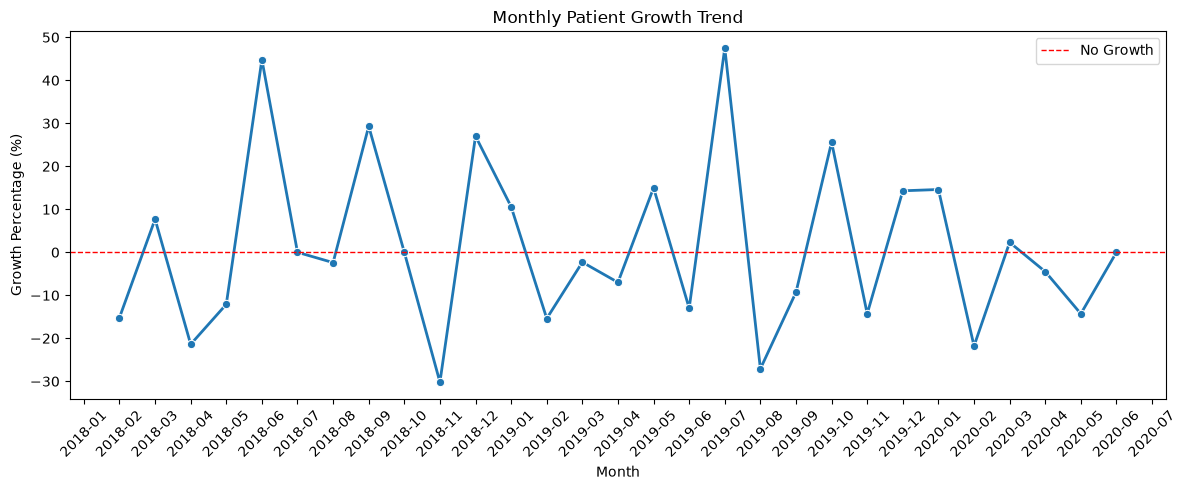

In [230]:
fig, ax = plt.subplots(figsize=(12,5))

sns.lineplot(
    x=monthly_patients.index.astype(str),
    y=monthly_patients['Growth_Percentage'],
    marker='o',
    linewidth=2,
    ax=ax
)


ax.axhline(
    y=0,
    linestyle='--',
    color='red',
    linewidth=1,
    label="No Growth"
)


ax.set_title("Monthly Patient Growth Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Growth Percentage (%)")

ax.tick_params(
    axis='x',
    rotation=45
)

ax.legend()

plt.tight_layout()

plt.show()

## 8. Export

Save your cleaned and merged data, and summarize your findings.

**Task 94:** Export each cleaned dataset (Patients, Doctors, Appointments, Medical Records, Payments) to a separate CSV file using `to_csv(index=False)`.

In [ ]:
patients_df.to_csv("Cleaned_Patients.csv", index=False)

Doctors_df.to_csv("Cleaned_Doctors.csv", index=False)

Appointments_df.to_csv("Cleaned_Appointments.csv", index=False)

Medical_Records_df.to_csv("Cleaned_Medical_Records.csv", index=False)

Payments_df.to_csv("Cleaned_Payments.csv", index=False)

**Task 95:** Export the final merged master DataFrame to a CSV file using `to_csv(index=False)`.

In [ ]:
all_tables.to_csv("Master Table.csv",index=False)